### Importando bibliotecas necessárias

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm

### Carregando o arquivo CSV e verificando as primeiras linhas do DataFrame

In [184]:
df = pd.read_csv('respostas_questionario.csv')
df.head()

,Carimbo de data/hora,Endereço de e-mail,"Declaração de suficiência dos esclarecimentos sobre a pesquisa:\r\nDeclaro que li as informações contidas nesse documento, fui devidamente informado(a) pelo(a) pesquisador (a) sobre os procedimentos que serão utilizados, riscos e desconfortos, benefícios, custo/reembolso dos participantes, confidencialidade da pesquisa, concordando ainda em participar da pesquisa. Foi-me garantido que posso retirar o consentimento a qualquer momento, sem qualquer penalidade ou prejuízo. Poderei consultar o pesquisador responsável (acima identificado) ou com o Comitê de Ética em Pesquisa com Seres Humanos do Campus Araguaia (CEP/ARAGUAIA), E-mail: cephumanos.cua@ufmt.br.com; Fone: (66) 3402-0744, sempre que entender necessário obter informações ou esclarecimentos sobre o projeto de pesquisa e minha participação no mesmo. Os resultados obtidos durante este estudo serão mantidos em sigilo, mas concordo que sejam divulgados em publicações científicas, desde que meus dados pessoais não sejam mencionados.","Declaro que li o Termo de Consentimento Livre e Esclarecido (TCLE) e que concordo em participar, como voluntário(a), da pesquisa descrita:","Declaro que faço parte do público alvo do estudo e contemplo todas as seguintes condições:\r\n\r\n- Assinalar ""Sim"" nas duas declarações iniciais; \r\n- Ter idade de 18 anos ou mais;\r\n- Ser discente/estudante de qualquer instituição de ensino superior na região de Barra do Garças - MT.",Qual o seu gênero?,A instituição em que você estuda é pública ou particular?,De qual área da sua instituição você pertence?,A qual curso você pertence?,Em qual semestre você está?,...,Com qual frequência você utiliza sistemas baseados em IA generativa em suas atividades acadêmicas?,"Você considera a interação IA e acadêmicos positiva, negativa ou neutra? Por quê?",Quão familiar você se considera com as capacidades da IA generativa? (0 para pouco e 5 para muito),Você acredita que o uso da IA generativa pode comprometer a autenticidade do seu trabalho acadêmico?,"Na sua experiência, a IA generativa tem sido eficiente nas suas atividades acadêmicas?","Se sim, por que você considera a IA generativa eficiente em suas atividades acadêmicas?",Você acredita que a IA generativa é melhor que os métodos tradicionais ?,"Se sim, selecione os motivos que justificam por que a IA Generativa é considerada melhor que os métodos tradicionais","No geral, como você avalia sua experiência ao utilizar ferramentas de IA generativa no ensino superior?",Você tem alguma sugestão ou comentário adicional sobre o uso de ferramentas de IA generativa na educação superior? (Resposta aberta)
0,30/07/2024 13:29:15,wesley.santos@sou.ufmt.br,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Masculino,Pública,Ciências Exatas e da Terra,Ciência da Computação,9º Semestre,...,Raramente,Positiva,0,Talvez,Sim,Auxilia em correções principalmente de textos,Não,NaN,Parcialmente Satisfeito,NaN
1,30/07/2024 13:34:26,evelynfelix515@gmail.com,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,"Linguística, Letras e Artes",Letras,5° Semestre,...,Mensalmente,Neutra. Pois otimiza tempo se você souber usar...,4,Talvez,Não,NaN,Não,NaN,Parcialmente Satisfeito,NaN
2,30/07/2024 13:38:37,nathalia.santos1@sou.ufmt.br,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,Ciências Exatas e da Terra,Engenharia Civil,7° Semestre,...,Raramente,"Neutra, ela auxilia para que os prazos sejam c...",1,Não,Não,NaN,Parcialmente,"Eficiência na Geração de Conteúdo, Variedade d...",Satisfeito,NaN
3,30/07/2024 13:49:30,amandabiomed2019@gmail.com,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,Ciências da Saúde,Biomedicina,4° Semestre,...,Semanalmente,Acredito que a característica da interação aca...,3,Si

# Análise Das Perguntas Demográficas com base nas áreas de estudo

### Área de Estudo

In [185]:
# Dicionário para agrupar as áreas (mantendo a capitalização correta)
areas_agrupadas = {
    'Ciências Agrárias': 'Ciências Agrárias',
    'Linguística, Letras e Artes': 'Ciências Humanas e Sociais',
    'Agronomia': 'Ciências Agrárias',
    'Ciências Biológicas': 'Ciências Biológicas',
    'Ciências da Saúde': 'Ciências Biológicas',
    'Educação física': 'Ciências Biológicas',
    'Ciências Exatas e da Terra': 'Ciências Exatas e da Terra',
    'Engenharias': 'Ciências Exatas e da Terra',
    'Ciências Humanas': 'Ciências Humanas e Sociais',
    'Ciências Sociais Aplicadas': 'Ciências Humanas e Sociais',
    'Direito': 'Ciências Humanas e Sociais',
    'DIREITO': 'Ciências Humanas e Sociais',
    'Linguística, Letras e Artes': 'Ciências Humanas e Sociais'
}


# Remover espaços extras
df['De qual área da sua instituição você pertence?'] = df['De qual área da sua instituição você pertence?'].str.strip()

# Aplicar a substituição e agrupar
df['Área de Estudo Agrupada'] = df['De qual área da sua instituição você pertence?'].replace(areas_agrupadas)

# Corrigir a area Direito para Ciências Humanas e Sociais
df.loc[df['De qual área da sua instituição você pertence?'].str.contains('Direito', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Humanas e Sociais'

# Corrigir Ciências Sociais Aplicadas para Ciências Humanas e Sociais
df.loc[df['De qual área da sua instituição você pertence?'].str.contains('Ciências Sociais Aplicadas', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Humanas e Sociais'

# Corrigir Linguística, Letras e Artes para Ciências Humanas e Sociais
df.loc[df['De qual área da sua instituição você pertence?'].str.contains('Linguística, Letras e Artes', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Humanas e Sociais'

# Corrigir Ciências Exatas e da Terra para Ciências Exatas e da Terra
df.loc[df['De qual área da sua instituição você pertence?'].str.contains('Ciências Exatas e da Terra', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Exatas e da Terra'

# Corrigir todos os cursos que tenha Direito ou DIREITO
df.loc[df['A qual curso você pertence?'].str.contains('Direito', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Humanas e Sociais'

# Corrigir curso de Educação Física
df.loc[df['A qual curso você pertence?'].str.contains('Educação Física', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Biológicas'

# Corrigir curso de Agronomia
df.loc[df['A qual curso você pertence?'].str.contains('Agronomia', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Agrárias'

# Corrigir curso de Pedagogia
df.loc[df['A qual curso você pertence?'].str.contains('Pedagogia', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Humanas e Sociais'

# Corrigir Psicologia
df.loc[df['A qual curso você pertence?'].str.contains('Psicologia', case=False, na=False), 'Área de Estudo Agrupada'] = 'Ciências Humanas e Sociais'

# Verificar áreas não mapeadas
areas_nao_mapeadas = df[~df['De qual área da sua instituição você pertence?'].isin(areas_agrupadas.keys())]
print("Áreas não mapeadas:", areas_nao_mapeadas['De qual área da sua instituição você pertence?'].unique())

# Calcular a contagem de ocorrências de cada área de estudo agrupada
contagem_areas_agrupadas = df['Área de Estudo Agrupada'].value_counts().reset_index()

# Ajustar o nome das colunas
contagem_areas_agrupadas.columns = ['Área de Estudo Agrupada', 'Contagem']

print(contagem_areas_agrupadas)

# Total de respostas
total_respostas = contagem_areas_agrupadas['Contagem'].sum()
print(f"Total de respostas: {total_respostas}")

# Porcentagem ao lado de cada área de estudo agrupada
print("\nNúmero de respostas por área de estudo agrupada e porcentagem ao lado:")
for area, contagem in zip(contagem_areas_agrupadas['Área de Estudo Agrupada'], contagem_areas_agrupadas['Contagem']):
    porcentagem = (contagem / contagem_areas_agrupadas['Contagem'].sum()) * 100
    print(f"{area}: {contagem} ({porcentagem:.1f}%)")

Áreas não mapeadas: []
      Área de Estudo Agrupada  Contagem
0  Ciências Humanas e Sociais        51
1  Ciências Exatas e da Terra        26
2           Ciências Agrárias        24
3         Ciências Biológicas        22
Total de respostas: 123

Número de respostas por área de estudo agrupada e porcentagem ao lado:
Ciências Humanas e Sociais: 51 (41.5%)
Ciências Exatas e da Terra: 26 (21.1%)
Ciências Agrárias: 24 (19.5%)
Ciências Biológicas: 22 (17.9%)


C:\Users\Luise\AppData\Local\Temp\ipykernel_23136\1533716084.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis')


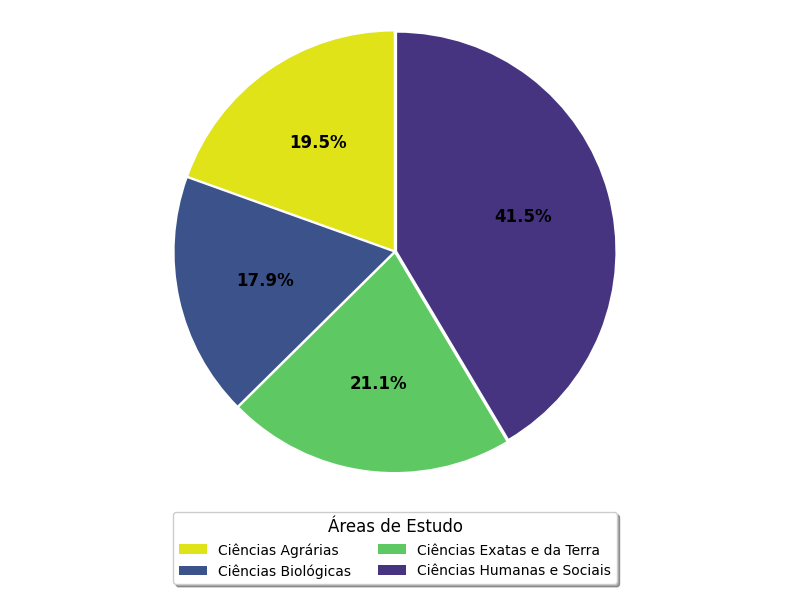


Dados do gráfico de pizza:
Ciências Agrárias: 19.5% (20 respostas)
Ciências Biológicas: 17.9% (18 respostas)
Ciências Exatas e da Terra: 21.1% (21 respostas)
Ciências Humanas e Sociais: 41.5% (41 respostas)


In [163]:
# Agrupar os dados por 'Área de Estudo Agrupada' e calcular a contagem total
df_grouped_areas = df.groupby('Área de Estudo Agrupada').size().reset_index(name='Contagem')

# Extrair os dados para o gráfico
labels = df_grouped_areas['Área de Estudo Agrupada']  # Nomes das áreas agrupadas
sizes = df_grouped_areas['Contagem'] / df_grouped_areas['Contagem'].sum() * 100  # Porcentagens

# Especificar cores da paleta viridis
viridis = cm.get_cmap('viridis')
colors = [viridis(0.95), viridis(0.25), viridis(0.75), viridis(0.15)]  # Valores específicos da paleta

# Criar o gráfico de pizza
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    # espaço entre todas as fatias
    explode=(0.01,) * len(sizes),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Personalizar os textos das porcentagens
for autotext in autotexts:
    autotext.set_color('black')  # Cor do texto
    autotext.set_fontsize(12)    # Tamanho da fonte
    autotext.set_fontweight('bold')  # Negrito

# Adicionar uma legenda
ax.legend(
    labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.2), 
    ncol=2, 
    title='Áreas de Estudo', 
    title_fontsize=12, 
    fontsize=10,
    fancybox=True,
    shadow=True
)

# Garantir que o gráfico seja circular
ax.axis('equal')

# Exibir o gráfico
plt.tight_layout()
plt.show()

# Imprimir as áreas de estudo agrupadas, suas contagens e porcentagens
print("\nDados do gráfico de pizza:")
for area, contagem in zip(labels, sizes):
    porcentagem = contagem / sum(sizes) * 100
    print(f"{area}: {contagem:.1f}% ({contagem:.0f} respostas)")


# salvar numa pasta chamada 'figuras'
fig.savefig('figuras/grafico_areas_estudo.png', bbox_inches='tight', dpi=300)

### Gênero

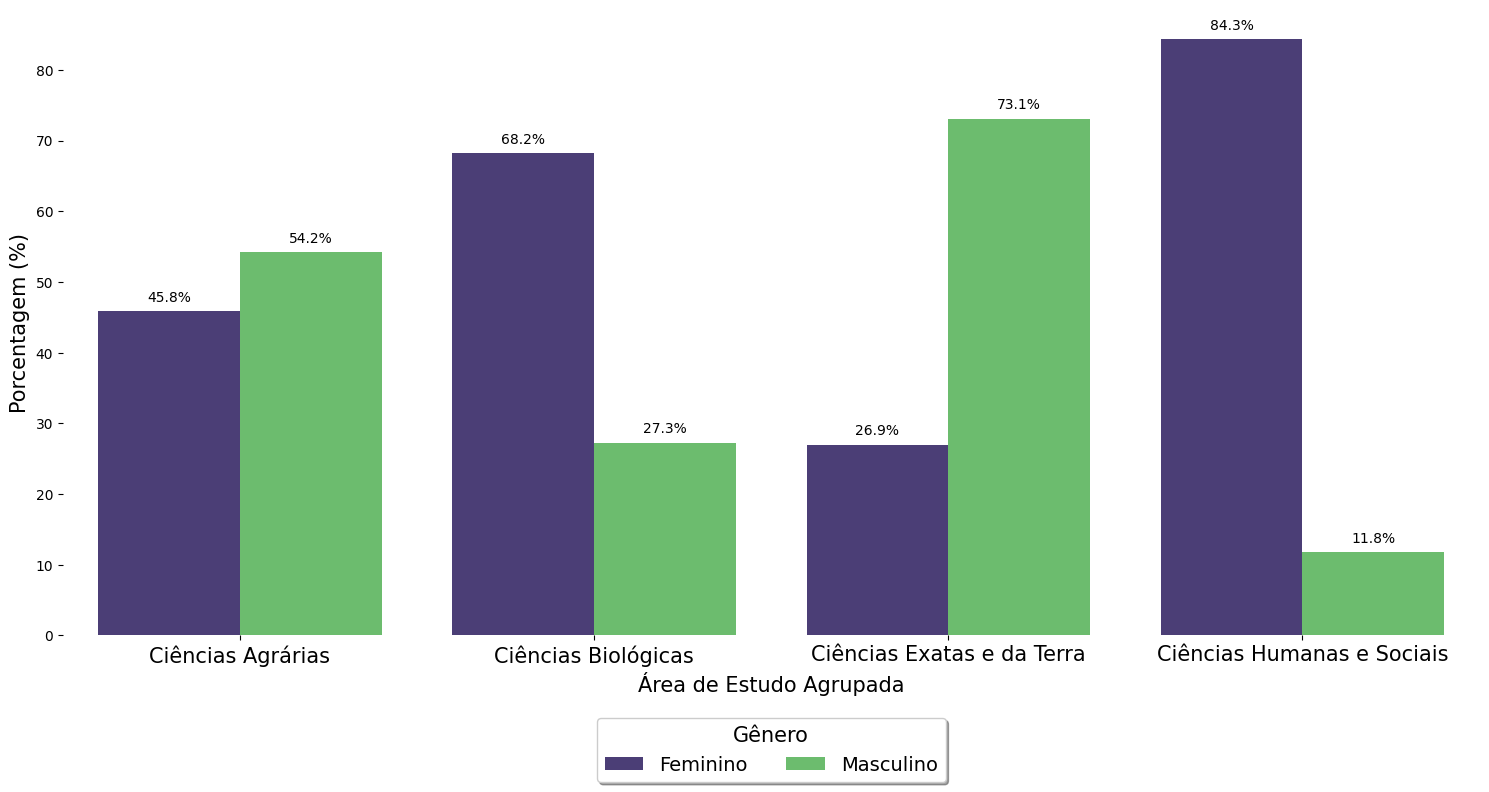


Dados do gráfico de barras:
Ciências Agrárias - Feminino: 45.8%
Ciências Agrárias - Masculino: 54.2%
Ciências Biológicas - Feminino: 68.2%
Ciências Biológicas - Masculino: 27.3%
Ciências Biológicas - nan: 4.5%
Ciências Exatas e da Terra - Feminino: 26.9%
Ciências Exatas e da Terra - Masculino: 73.1%
Ciências Humanas e Sociais - Feminino: 84.3%
Ciências Humanas e Sociais - Masculino: 11.8%
Ciências Humanas e Sociais - nan: 3.9%


<Figure size 640x480 with 0 Axes>

In [187]:
# Agrupar os dados por 'Área de Estudo Agrupada' e 'Gênero', calculando a contagem
df_grouped = df.groupby(['Área de Estudo Agrupada', 'Qual o seu gênero?']).size().reset_index(name='Contagem')

# Calcular a porcentagem de cada gênero dentro de cada área de estudo
df_grouped['Total_Area'] = df_grouped.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')
df_grouped['Percentual'] = (df_grouped['Contagem'] / df_grouped['Total_Area']) * 100

# Filtrar os dados para remover combinações com contagem zero
df_grouped = df_grouped[df_grouped['Contagem'] > 0]

# Ordenar os valores de 'Qual o seu gênero' para garantir a ordem correta na legenda
df_grouped['Qual o seu gênero?'] = pd.Categorical(
    df_grouped['Qual o seu gênero?'],
    categories=['Feminino', 'Masculino'],
    ordered=True
)

# Definir cores da paleta viridis
# Cores para Feminino, Masculino e Prefiro não dizer
viridis = plt.cm.viridis
colors = { 'Feminino': viridis(0.15), 'Masculino': viridis(0.75)}  

# Criar o gráfico de barras
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=df_grouped, 
    x='Área de Estudo Agrupada', 
    y='Percentual', 
    hue='Qual o seu gênero?', 
    palette=colors  # Usar as cores da paleta viridis
)

# Adicionar rótulos de porcentagem acima das barras
# Adicionar os percentuais sobre as barras
for patch, row in zip(ax.patches, df_grouped.itertuples()):
    x = patch.get_x() + patch.get_width() / 2.0
    y = patch.get_height()
    if y > 0:  # Adicionar texto apenas para barras com altura maior que 0
        plt.text(x, y + 1, f'{y:.1f}%', ha='center', va='bottom', fontsize=10, color='black')



# Configurar título e rótulos dos eixos
# plt.title('Porcentagem de Gêneros por Área de Estudo Agrupada', fontsize=16, fontweight='bold')
plt.xlabel('Área de Estudo Agrupada', fontsize=15)
plt.ylabel('Porcentagem (%)', fontsize=15)
plt.xticks(rotation=0, fontsize=15)

legend_elements = [
    Patch(facecolor=colors['Feminino'], label='Feminino'),  # Cor para Feminino
    Patch(facecolor=colors['Masculino'], label='Masculino')  # Cor para Masculino
]

# Ajustar a legenda
plt.legend(
    title='Gênero', 
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    fancybox=True,
    shadow=True, 
    fontsize=14, 
    title_fontsize=15)

# Ajustar layout
plt.tight_layout()

# Retirar o box
plt.box(False)
plt.grid(False)

# Exibir o gráfico
plt.show()

# Salvar o gráfico
plt.savefig('figuras/grafico_genero_areas_estudo.png')

# imprimir os dados do gráfico
print("\nDados do gráfico de barras:")
for area, genero, percentual in zip(df_grouped['Área de Estudo Agrupada'], df_grouped['Qual o seu gênero?'], df_grouped['Percentual']):
    print(f"{area} - {genero}: {percentual:.1f}%") 

### Instituição (Pública ou Privada)

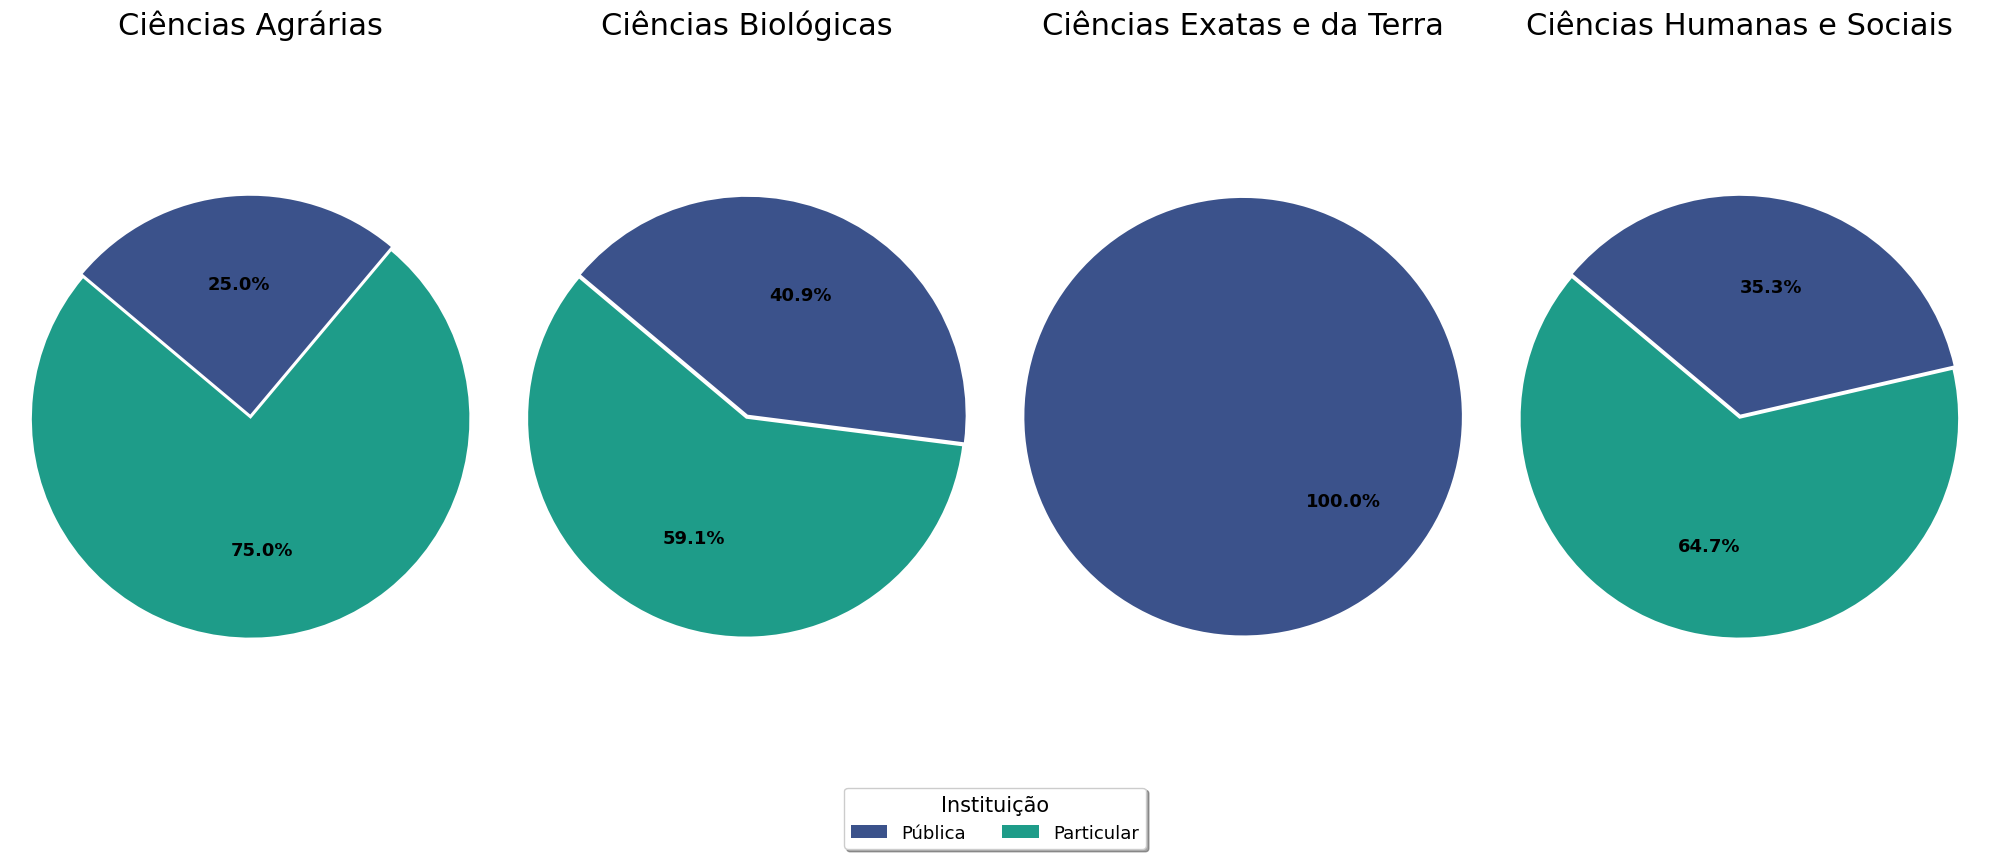


Dados do gráfico de pizza:
Ciências Agrárias - Particular: 75.0%
Ciências Agrárias - Pública: 25.0%
Ciências Biológicas - Particular: 59.1%
Ciências Biológicas - Pública: 40.9%
Ciências Exatas e da Terra - Pública: 100.0%
Ciências Humanas e Sociais - Particular: 64.7%
Ciências Humanas e Sociais - Pública: 35.3%


In [217]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import pandas as pd

# Agrupar os dados
df_grouped_instituicao = df.groupby(['Área de Estudo Agrupada', 'A instituição em que você estuda é pública ou particular?']).size().reset_index(name='Contagem')
df_grouped_instituicao['Total_Area'] = df_grouped_instituicao.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')
df_grouped_instituicao['Percentual'] = (df_grouped_instituicao['Contagem'] / df_grouped_instituicao['Total_Area']) * 100
df_grouped_instituicao = df_grouped_instituicao[df_grouped_instituicao['Contagem'] > 0]

# Ordenar os valores para a legenda
df_grouped_instituicao['A instituição em que você estuda é pública ou particular?'] = pd.Categorical(
    df_grouped_instituicao['A instituição em que você estuda é pública ou particular?'],
    categories=['Pública', 'Particular'],
    ordered=True
)

# Definir cores
viridis = plt.cm.viridis
colors_instituicao = {'Pública': viridis(0.25), 'Particular': viridis(0.55)}

# Criar os gráficos de pizza lado a lado
areas_unicas = df_grouped_instituicao['Área de Estudo Agrupada'].unique()
fig, axes = plt.subplots(1, len(areas_unicas), figsize=(20, 8))

for ax, area in zip(axes, areas_unicas):
    dados_area = df_grouped_instituicao[df_grouped_instituicao['Área de Estudo Agrupada'] == area]

    # Pizza
    wedges, texts, autotexts = ax.pie(
        dados_area['Percentual'], 
        labels=None,  # Remove os labels ao lado da pizza
        autopct='%1.1f%%',
        startangle=140,
        colors=[colors_instituicao[tipo] for tipo in dados_area['A instituição em que você estuda é pública ou particular?']],
        # coloca um espaço entre as fatias
        explode=(0.01,) * len(dados_area),
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    # Estética dos textos
    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_fontweight('bold')

    # Título centralizado para cada gráfico
    ax.set_title(area, fontsize=22, pad=15)
    ax.axis('equal')

# Legenda fora do gráfico
legend_elements = [
    Patch(facecolor=colors_instituicao['Pública'], label='Pública'),
    Patch(facecolor=colors_instituicao['Particular'], label='Particular')
]

fig.legend(
    handles=legend_elements,
    title='Instituição',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fancybox=True,
    shadow=True,
    fontsize=13,
    title_fontsize=15
)

plt.tight_layout()
plt.show()

# imprimir os dados do gráfico
print("\nDados do gráfico de pizza:")
for area, tipo, percentual in zip(df_grouped_instituicao['Área de Estudo Agrupada'], df_grouped_instituicao['A instituição em que você estuda é pública ou particular?'], df_grouped_instituicao['Percentual']):
    print(f"{area} - {tipo}: {percentual:.1f}%")
# Salvar o gráfico
fig.savefig('figuras/grafico_instituicao_areas_estudo.png', bbox_inches='tight', dpi=300)

### Cursos

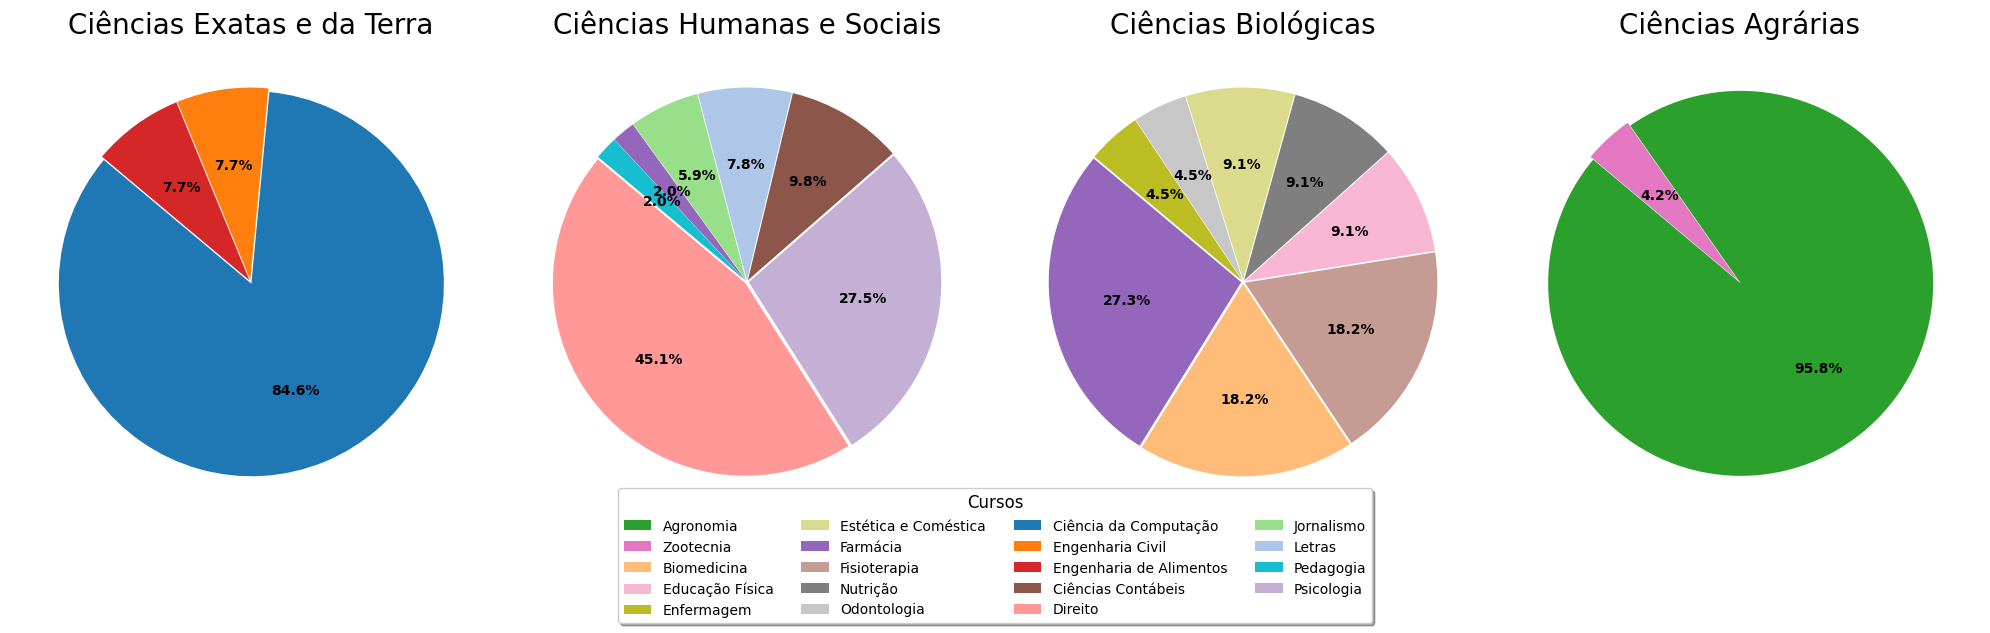

Área: Ciências Agrárias
Cursos: ['Agronomia' 'Zootecnia']
Porcentagem de cada curso:
  Agronomia: 18.7%
  Zootecnia: 0.8%

Área: Ciências Biológicas
Cursos: ['Biomedicina' 'Farmácia' 'Fisioterapia' 'Educação Física' 'Nutrição'
 'Odontologia' 'Enfermagem' 'Estética e Coméstica']
Porcentagem de cada curso:
  Biomedicina: 3.3%
  Farmácia: 5.7%
  Fisioterapia: 3.3%
  Educação Física: 1.6%
  Nutrição: 1.6%
  Odontologia: 0.8%
  Enfermagem: 0.8%
  Estética e Coméstica: 1.6%

Área: Ciências Exatas e da Terra
Cursos: ['Ciência da Computação' 'Engenharia Civil' 'Engenharia de Alimentos']
Porcentagem de cada curso:
  Ciência da Computação: 17.9%
  Engenharia Civil: 1.6%
  Engenharia de Alimentos: 1.6%

Área: Ciências Humanas e Sociais
Cursos: ['Letras' 'Jornalismo' 'Direito' 'Psicologia' 'Farmácia'
 'Ciências Contábeis' 'Pedagogia']
Porcentagem de cada curso:
  Letras: 3.3%
  Jornalismo: 2.4%
  Direito: 18.7%
  Psicologia: 11.4%
  Farmácia: 5.7%
  Ciências Contábeis: 4.1%
  Pedagogia: 0.8%



In [166]:

# Obter os cursos únicos do DataFrame
cursos_unicos = df['A qual curso você pertence?'].unique()

# Escolher uma paleta discreta com cores suficientes. Aqui usamos 'tab20'.
num_cores = len(cursos_unicos)
palette = sns.color_palette('tab20', num_cores)

# Criar um dicionário para associar cada curso a uma cor fixa
global_colors = {curso: palette[i] for i, curso in enumerate(cursos_unicos)}

# Criar um mapeamento de curso para área (usando o primeiro registro encontrado para cada curso)
curso_area = df.groupby('A qual curso você pertence?')['Área de Estudo Agrupada'].first().to_dict()

# Definir a ordem desejada das áreas
ordem_areas = {
    'Ciências Agrárias': 1,
    'Ciências Biológicas': 2,
    'Ciências Exatas e da Terra': 3,
    'Ciências Humanas e Sociais': 4
}

# Ordenar a lista de cursos com base na área e, dentro da mesma área, em ordem alfabética
cursos_ordenados = sorted(cursos_unicos, key=lambda curso: (ordem_areas.get(curso_area.get(curso, ""), 99), curso))

# Obter a lista de áreas únicas (para os gráficos)
areas_unicas = df['Área de Estudo Agrupada'].unique()

# Definir 1 linha e número de colunas igual ao número de áreas
n_colunas = len(areas_unicas)
n_linhas = 1

# Criar os subplots em linha única
fig, axs = plt.subplots(n_linhas, n_colunas, figsize=(5 * n_colunas, 6))
axs = axs.flatten()  # Facilitar o acesso aos eixos

# Gerar um gráfico de pizza por área de estudo
for i, area in enumerate(areas_unicas):
    df_area = df[df['Área de Estudo Agrupada'] == area]
    
    # Contar o número de respondentes por curso na área
    cursos_count = df_area['A qual curso você pertence?'].value_counts()
    
    # Obter as cores fixas para cada curso desta área, com base no dicionário global
    cores = [global_colors[curso] for curso in cursos_count.index]
    
    # Plotar o gráfico de pizza
    axs[i].pie(
        cursos_count,
        labels=None,  # Remove os labels externos da pizza
        autopct='%1.1f%%',
        startangle=140,
        textprops={'fontsize': 10, 'fontweight': 'bold'},
        colors=cores,
        explode=(0.01,) * len(cursos_count)
    )
    axs[i].set_title(f'{area}', fontsize=20)

# Criar a legenda global com os cursos ordenados (apenas o nome do curso)
legend_elements = [Patch(facecolor=global_colors[curso], label=curso) for curso in cursos_ordenados]
fig.legend(
    handles=legend_elements,
    title='Cursos',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=4,
    fancybox=True,
    shadow=True,
    fontsize=10,
    title_fontsize=12
)

# Ajuste final do layout e título
plt.tight_layout()
# plt.suptitle('Distribuição dos Cursos por Área de Estudo', fontsize=16, fontweight='bold', y=1.05)
plt.show()

# imprimir os cursos de cada área de estudo e sua porcentagem
areas_unicas = df['Área de Estudo Agrupada'].unique()
areas_unicas = sorted(areas_unicas, key=lambda x: ordem_areas.get(x, 99))

for area in areas_unicas:
    cursos_area = df[df['Área de Estudo Agrupada'] == area]['A qual curso você pertence?'].unique()
    print(f"Área: {area}")
    print("Cursos:", cursos_area)
    print("Porcentagem de cada curso:")
    for curso in cursos_area:
        porcentagem = (df[df['A qual curso você pertence?'] == curso].shape[0] / df.shape[0]) * 100
        print(f"  {curso}: {porcentagem:.1f}%")
    print()

### Semestre

C:\Users\Luise\AppData\Local\Temp\ipykernel_23136\1037271705.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('tab10', len(sorted_semestres))


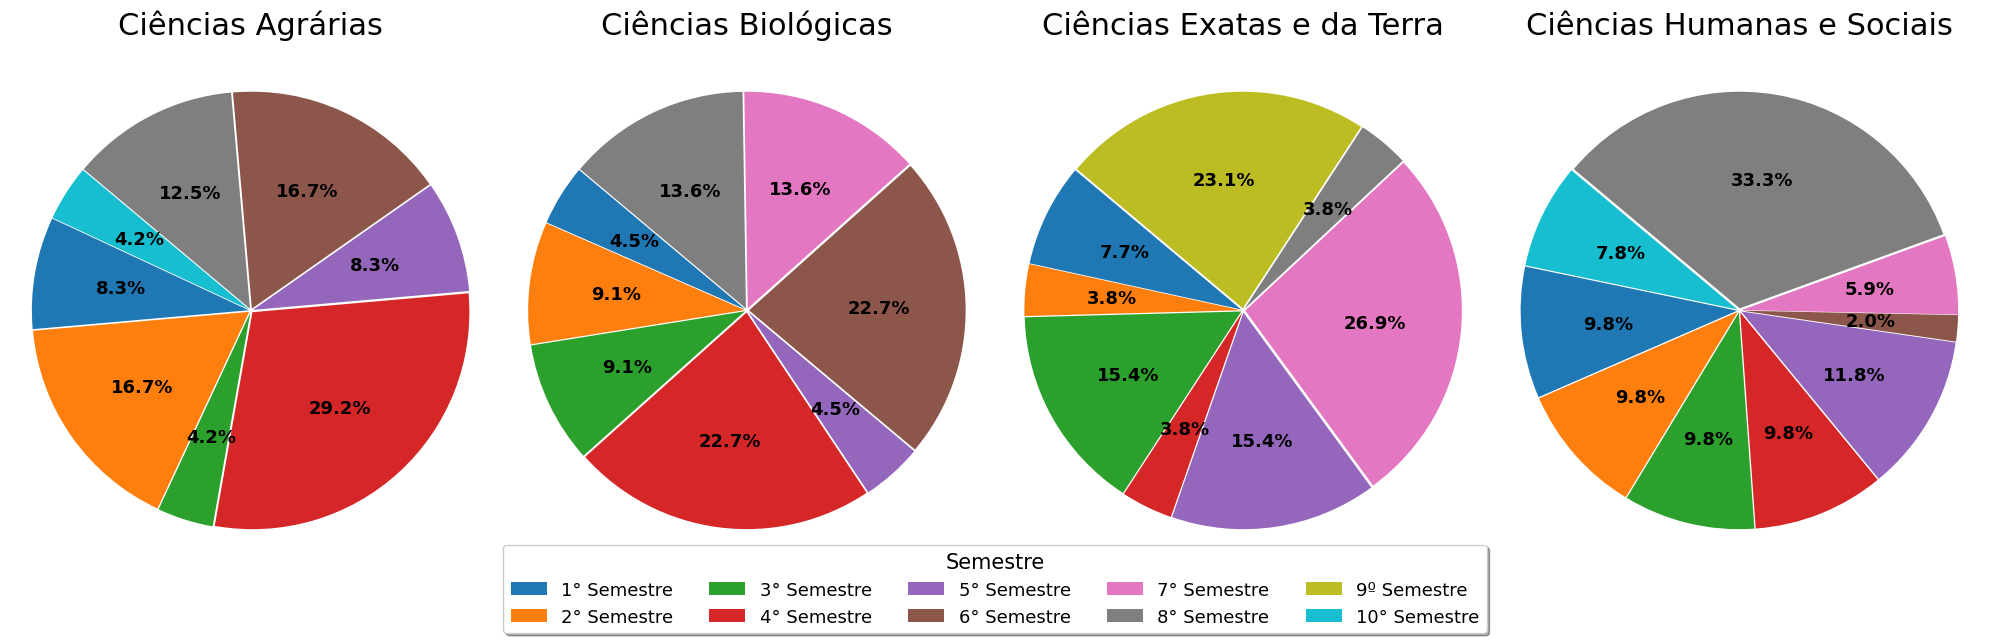

       Área de Estudo Agrupada Em qual semestre você está?  Contagem  \
0            Ciências Agrárias                10° Semestre         1   
1            Ciências Agrárias                 1° Semestre         2   
2            Ciências Agrárias                 2° Semestre         4   
3            Ciências Agrárias                 3° Semestre         1   
4            Ciências Agrárias                 4° Semestre         7   
5            Ciências Agrárias                 5° Semestre         2   
6            Ciências Agrárias                 6° Semestre         4   
7            Ciências Agrárias                 8° Semestre         3   
8          Ciências Biológicas                 1° Semestre         1   
9          Ciências Biológicas                 2° Semestre         2   
10         Ciências Biológicas                 3° Semestre         2   
11         Ciências Biológicas                 4° Semestre         5   
12         Ciências Biológicas                 5° Semestre      

In [167]:
import re

# Agrupar os dados por 'Área de Estudo Agrupada' e 'Em qual semestre você está?'
df_grouped_semestre = df.groupby(['Área de Estudo Agrupada', 'Em qual semestre você está?']).size().reset_index(name='Contagem')

# Calcular o total de respostas por área de estudo
df_grouped_semestre['Total_Area'] = df_grouped_semestre.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')

# Calcular a porcentagem de cada semestre dentro de cada área de estudo
df_grouped_semestre['Percentual'] = (df_grouped_semestre['Contagem'] / df_grouped_semestre['Total_Area']) * 100

# Obter os semestres únicos
semestres_unicos = df_grouped_semestre['Em qual semestre você está?'].unique()

# Ordenar os semestres extraindo o número com regex
sorted_semestres = sorted(semestres_unicos, key=lambda s: int(re.search(r'\d+', s).group()))

# Gerar cores únicas para cada semestre usando a paleta 'tab10' com base nos semestres ordenados
viridis = cm.get_cmap('tab10', len(sorted_semestres))
cores_semestres = {semestre: viridis(i / len(sorted_semestres)) for i, semestre in enumerate(sorted_semestres)}

# Restante do código permanece inalterado...
n_colunas = len(df_grouped_semestre['Área de Estudo Agrupada'].unique())
fig, axes = plt.subplots(1, n_colunas, figsize=(5 * n_colunas, 6))

for ax, area in zip(axes, df_grouped_semestre['Área de Estudo Agrupada'].unique()):
    dados_area_semestre = df_grouped_semestre[df_grouped_semestre['Área de Estudo Agrupada'] == area]
    cores = [cores_semestres[semestre] for semestre in dados_area_semestre['Em qual semestre você está?']]
    wedges, texts, autotexts = ax.pie(
        dados_area_semestre['Percentual'], 
        labels=None,
        autopct='%1.1f%%',
        startangle=140,
        colors=cores,
        explode=(0.01,) * len(dados_area_semestre),
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )
    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_fontweight('bold')
    ax.set_title(area, fontsize=22)
    ax.axis('equal') 

legend_elements = [
    Patch(facecolor=cores_semestres[semestre], label=semestre) for semestre in sorted_semestres
]

fig.legend(
    handles=legend_elements,
    title='Semestre',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=5,
    fancybox=True,
    shadow=True,
    fontsize=13,
    title_fontsize=15
)

plt.tight_layout()
plt.show()

print(df_grouped_semestre[['Área de Estudo Agrupada', 'Em qual semestre você está?', 'Contagem', 'Percentual']])


# Experiência com IAG

### Experiência Pessoal

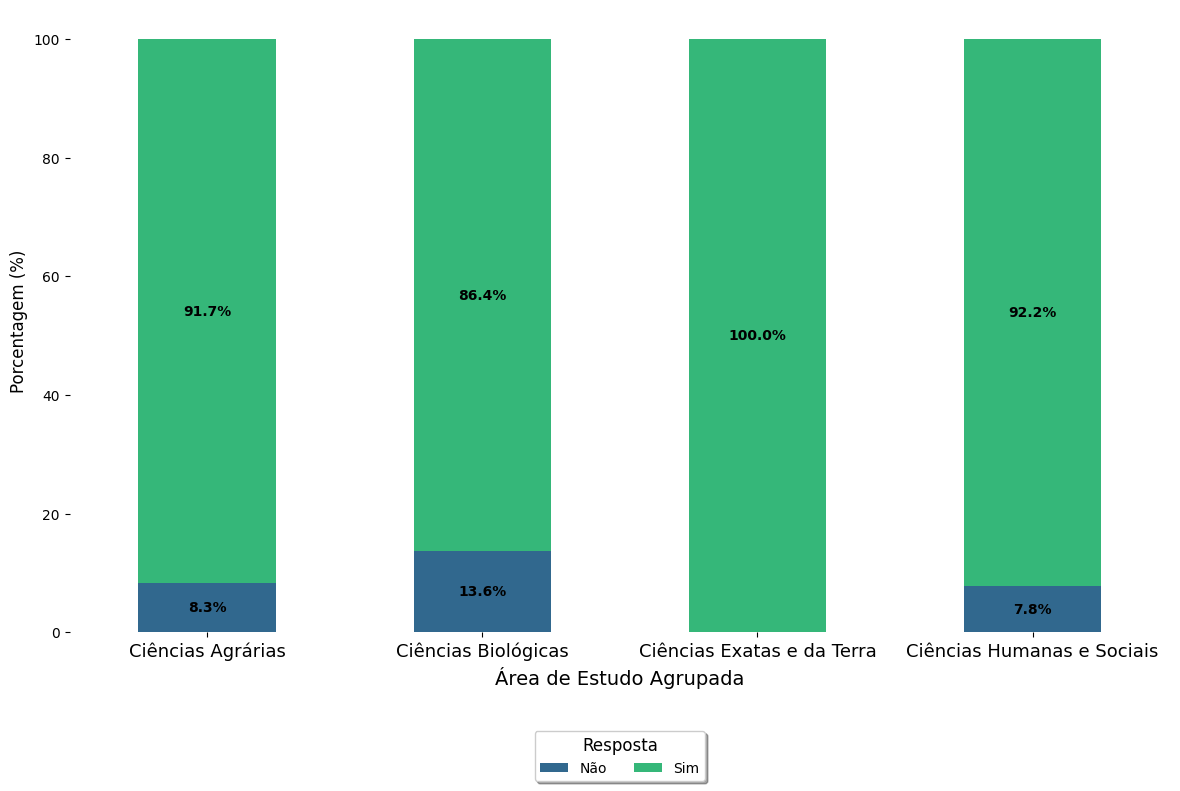


Porcentagem de experiência pessoal com IA Generativa por área de estudo:
Você já teve contato ou experiência com alguma ferramenta de Inteligência Artificial Generativa? Seja por lazer, curiosidade, etc        Não  \
Área de Estudo Agrupada                                                                                                                        
Ciências Agrárias                                                                                                                   8.333333   
Ciências Biológicas                                                                                                                13.636364   
Ciências Exatas e da Terra                                                                                                               NaN   
Ciências Humanas e Sociais                                                                                                          7.843137   

Você já teve contato ou experiência com alguma ferramenta de 

<Figure size 640x480 with 0 Axes>

In [196]:
# Corrigir nomes das colunas, se necessário
df.columns = df.columns.str.strip()
# Define the column name for personal experience with generative AI
coluna_experienciapessoal_ia = 'Você já teve contato ou experiência com alguma ferramenta de Inteligência Artificial Generativa? Seja por lazer, curiosidade, etc'
coluna_experienciapessoal_ia = coluna_experienciapessoal_ia.strip()

# Calcular a porcentagem de experiência pessoal por área
experiencia_por_area = df.groupby('Área de Estudo Agrupada')[coluna_experienciapessoal_ia].value_counts(normalize=True).unstack() * 100

# Criar a paleta de cores
cores_viridis = sns.color_palette("viridis", len(experiencia_por_area.columns))

# Criar o gráfico de barras empilhadas
ax = experiencia_por_area.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 8), 
    color=cores_viridis
)

# Adicionar rótulos de porcentagem maiores que 0
for container in ax.containers:
    labels = [
        f'{v:.1f}%' if v > 0 else ''  # mostra somente se for > 0
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold')

# Título e eixos
# plt.title('Porcentagem de Experiência Pessoal com IA Generativa por Área de Estudo', fontsize=16, fontweight='bold')
plt.xlabel('Área de Estudo Agrupada', fontsize=14)
plt.xticks(rotation=0, ha='center', fontsize=13)  # horizontal e centralizado
plt.ylabel('Porcentagem (%)', fontsize=12)

# Legenda
plt.legend(
    title='Resposta', 
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2, 
    fontsize=10, 
    title_fontsize=12, 
    fancybox=True, 
    shadow=True
)

# Limpar bordas e grade
plt.box(False)
plt.grid(False)

# Layout final
plt.tight_layout()

# Mostrar gráfico
plt.show()

# Mostrar dados
print("\nPorcentagem de experiência pessoal com IA Generativa por área de estudo:")
print(experiencia_por_area)

# Guardar o gráfico
plt.savefig('figuras/grafico_experiencia_ia_areas_estudo.png', bbox_inches='tight', dpi=300)

### Experiência Acadêmica

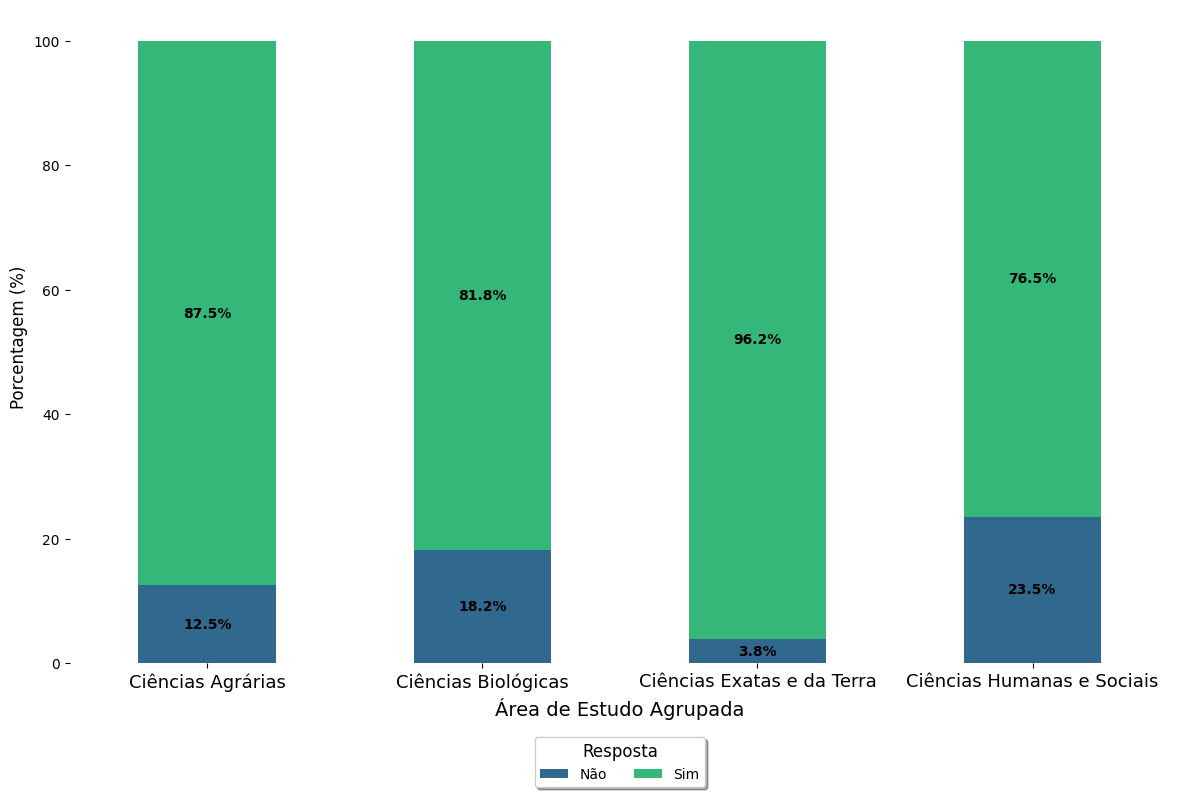


Porcentagem de experiência acadêmica com IA Generativa por área de estudo:
Você já teve contato ou experiência com alguma ferramenta de IA generativa com relação à sua área acadêmica? Para trabalhos acadêmicos ou trabalho profissional.        Não  \
Área de Estudo Agrupada                                                                                                                                                       
Ciências Agrárias                                                                                                                                                 12.500000   
Ciências Biológicas                                                                                                                                               18.181818   
Ciências Exatas e da Terra                                                                                                                                         3.846154   
Ciências Humanas e Sociais                       

In [198]:
# Nome da coluna para análise
coluna_experiencia_academica = 'Você já teve contato ou experiência com alguma ferramenta de IA generativa com relação à sua área acadêmica? Para trabalhos acadêmicos ou trabalho profissional.'

# Corrigir nomes das colunas, se necessário
df.columns = df.columns.str.strip()

# Calcular a porcentagem de respostas por categoria
experiencia_academica = df[coluna_experiencia_academica].value_counts(normalize=True) * 100

# Criar a paleta de cores
cores_viridis = sns.color_palette("viridis", len(experiencia_academica))


# Criar patches para a legenda
legend_patches = [
    Patch(facecolor=cores_viridis[i], edgecolor='black', label=experiencia_academica.index[i])
    for i in range(len(experiencia_academica))
]

# Adicionar a legenda
# Agrupar os dados por 'Área de Estudo Agrupada' e calcular a porcentagem de respostas
experiencia_academica_por_area = df.groupby('Área de Estudo Agrupada')[coluna_experiencia_academica].value_counts(normalize=True).unstack() * 100

# Criar a paleta de cores
cores_viridis = sns.color_palette("viridis", len(experiencia_academica_por_area.columns))

# Criar o gráfico de barras empilhadas
ax = experiencia_academica_por_area.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 8), 
    color=cores_viridis
)

# Adicionar rótulos de porcentagem maiores que 0
for container in ax.containers:
    labels = [
        f'{v:.1f}%' if v > 0 else ''  # mostra somente se for > 0
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold')

# Título e eixos
# plt.title('Porcentagem de Experiência com IAG para Fins Acadêmicos por Área de Estudo', fontsize=16, fontweight='bold')
plt.xlabel('Área de Estudo Agrupada', fontsize=14)
plt.xticks(rotation=0, ha='center', fontsize=13)  # horizontal e centralizado
plt.ylabel('Porcentagem (%)', fontsize=12)

# Legenda
plt.legend(
    title='Resposta', 
    loc='lower center',
    bbox_to_anchor=(0.5, -0.20),
    ncol=2, 
    fontsize=10, 
    title_fontsize=12, 
    fancybox=True, 
    shadow=True,
)

# Limpar bordas e grade
plt.box(False)
plt.grid(False)

# Layout final
plt.tight_layout()

# Mostrar gráfico
plt.show()

# Mostrar dados de cada área de estudo e sua porcentagem 
print("\nPorcentagem de experiência acadêmica com IA Generativa por área de estudo:")
print(experiencia_academica_por_area)


### Motivos de Utilização de IAG para fins acadêmicos

C:\Users\Luise\AppData\Local\Temp\ipykernel_23136\921271228.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(motivos_atuais, fontsize=11)


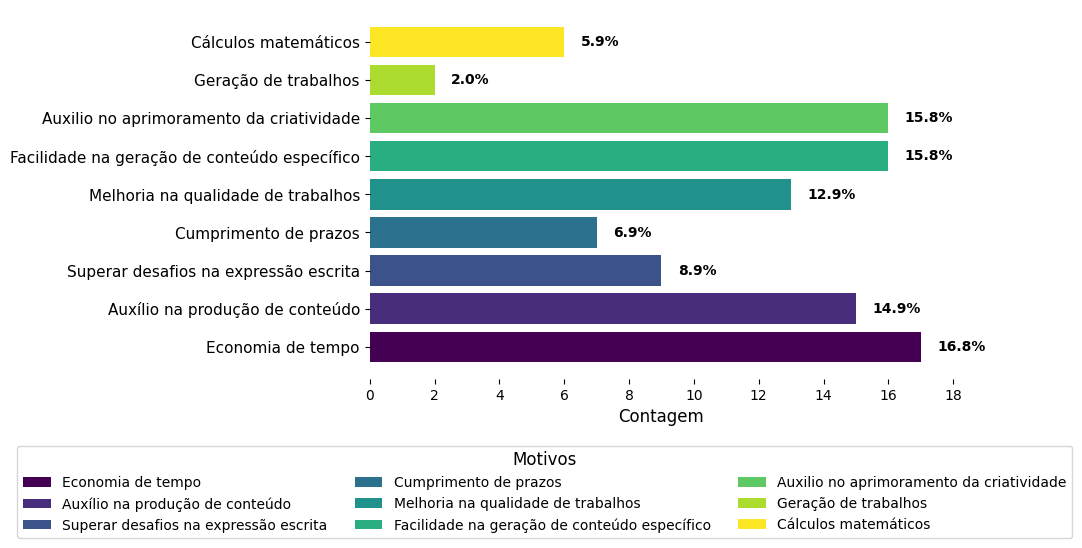

C:\Users\Luise\AppData\Local\Temp\ipykernel_23136\921271228.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(motivos_atuais, fontsize=11)



Motivos em Ciências Exatas e da Terra:
Economia de tempo: 17 (16.8%)
Auxílio na produção de conteúdo: 15 (14.9%)
Superar desafios na expressão escrita: 9 (8.9%)
Cumprimento de prazos: 7 (6.9%)
Melhoria na qualidade de trabalhos: 13 (12.9%)
Facilidade na geração de conteúdo específico: 16 (15.8%)
Auxilio no aprimoramento da criatividade: 16 (15.8%)
Geração de trabalhos: 2 (2.0%)
Cálculos matemáticos: 6 (5.9%)


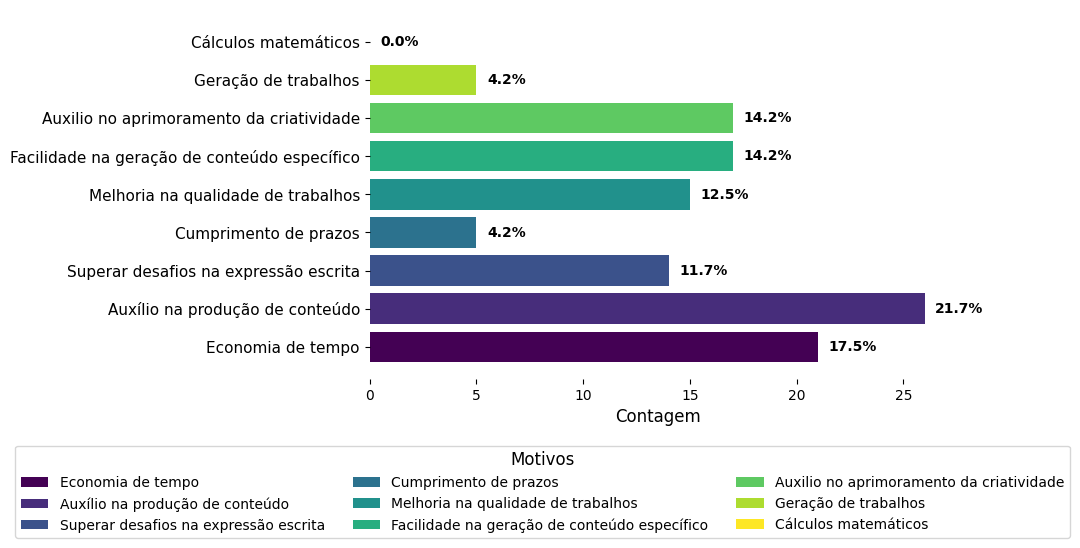


Motivos em Ciências Humanas e Sociais:
Economia de tempo: 21 (17.5%)
Auxílio na produção de conteúdo: 26 (21.7%)
Superar desafios na expressão escrita: 14 (11.7%)
Cumprimento de prazos: 5 (4.2%)
Melhoria na qualidade de trabalhos: 15 (12.5%)
Facilidade na geração de conteúdo específico: 17 (14.2%)
Auxilio no aprimoramento da criatividade: 17 (14.2%)
Geração de trabalhos: 5 (4.2%)
Cálculos matemáticos: 0 (0.0%)


C:\Users\Luise\AppData\Local\Temp\ipykernel_23136\921271228.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(motivos_atuais, fontsize=11)


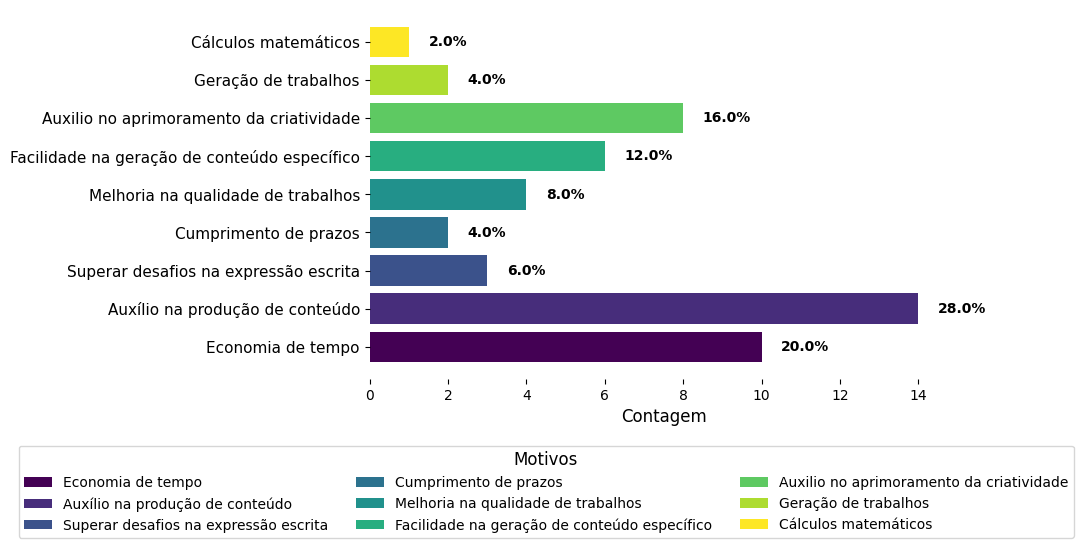


Motivos em Ciências Biológicas:
Economia de tempo: 10 (20.0%)
Auxílio na produção de conteúdo: 14 (28.0%)
Superar desafios na expressão escrita: 3 (6.0%)
Cumprimento de prazos: 2 (4.0%)
Melhoria na qualidade de trabalhos: 4 (8.0%)
Facilidade na geração de conteúdo específico: 6 (12.0%)
Auxilio no aprimoramento da criatividade: 8 (16.0%)
Geração de trabalhos: 2 (4.0%)
Cálculos matemáticos: 1 (2.0%)


C:\Users\Luise\AppData\Local\Temp\ipykernel_23136\921271228.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(motivos_atuais, fontsize=11)


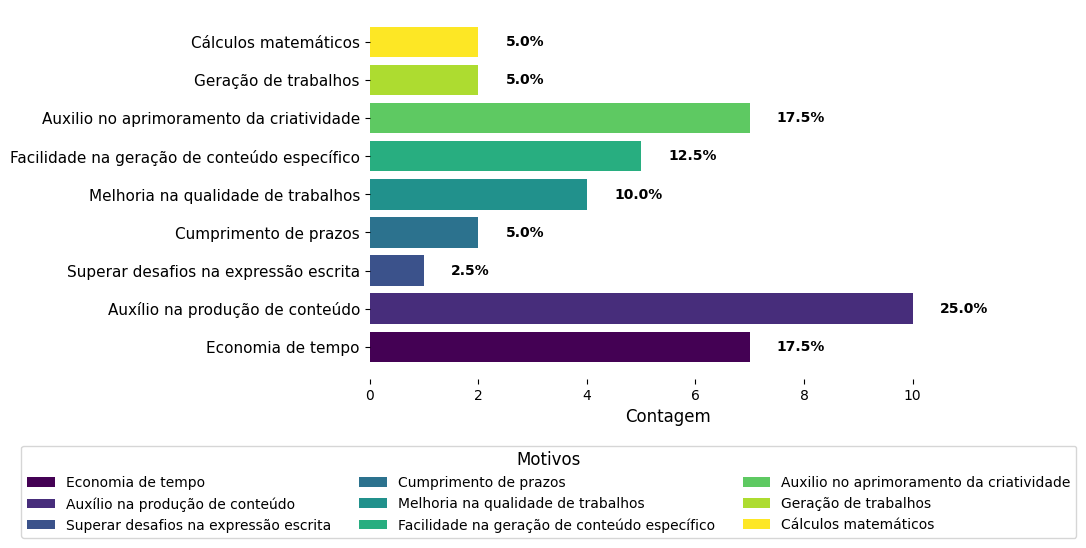


Motivos em Ciências Agrárias:
Economia de tempo: 7 (17.5%)
Auxílio na produção de conteúdo: 10 (25.0%)
Superar desafios na expressão escrita: 1 (2.5%)
Cumprimento de prazos: 2 (5.0%)
Melhoria na qualidade de trabalhos: 4 (10.0%)
Facilidade na geração de conteúdo específico: 5 (12.5%)
Auxilio no aprimoramento da criatividade: 7 (17.5%)
Geração de trabalhos: 2 (5.0%)
Cálculos matemáticos: 2 (5.0%)


In [170]:
# Lista de motivos
motivos = [
    "Economia de tempo",
    "Auxílio na produção de conteúdo",
    "Superar desafios na expressão escrita",
    "Cumprimento de prazos",
    "Melhoria na qualidade de trabalhos",
    "Facilidade na geração de conteúdo específico",
    "Auxilio no aprimoramento da criatividade",
    "Geração de trabalhos",
    "Cálculos matemáticos"
]

# Nome da coluna com os motivos
coluna_respostas = 'Qual é o principal motivo para você utilizá-la em sua área acadêmica?'
coluna_area = 'Área de Estudo Agrupada'

# Lista das áreas de estudo
areas_estudo = df[coluna_area].dropna().unique()

# Loop para criar um gráfico por área de estudo
for area in areas_estudo:
    df_area = df[df[coluna_area] == area]
    
    # Inicializar contagem de motivos
    contagem_motivos = {motivo: 0 for motivo in motivos}
    
    for resposta in df_area[coluna_respostas].dropna():
        for motivo in motivos:
            if motivo in resposta:
                contagem_motivos[motivo] += 1
    
    # Dados para o gráfico
    motivos_atuais = list(contagem_motivos.keys())
    contagens = list(contagem_motivos.values())
    total_respostas = sum(contagens)
    porcentagens = [(count / total_respostas) * 100 if total_respostas > 0 else 0 for count in contagens]
    
    # Criar gráfico horizontal
    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(motivos)))
    bars = plt.barh(motivos_atuais, contagens, color=colors)
    plt.xlabel('Contagem', fontsize=12)
    # plt.title(f'Motivos para Utilização da IA na Área Acadêmica – {area}', x=0.3, fontsize=14, fontweight='bold', pad=20)
    plt.xlim(0, max(contagens) + 1)

    # Adicionar porcentagens
    for bar, percent in zip(bars, porcentagens):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{percent:.1f}%', va='center', fontsize=10, fontweight='bold')
    
    # Negrito nos rótulos
    ax = plt.gca()
    ax.set_yticklabels(motivos_atuais, fontsize=11)

    # Legenda com as cores
    legend_elements = [Patch(facecolor=colors[i], label=motivos[i]) for i in range(len(motivos))]
    plt.legend(title="Motivos",
               title_fontsize=12,
               fontsize=10, 
               handles=legend_elements, 
               loc='lower center', 
               bbox_to_anchor=(0.3, -0.45), 
               ncol=3)

    # Estética
    plt.grid(False)
    plt.box(False)
    plt.tight_layout()
    plt.show()

    # Impressão dos dados
    print(f"\nMotivos em {area}:")
    for motivo, contagem, porcentagem in zip(motivos_atuais, contagens, porcentagens):
        print(f"{motivo}: {contagem} ({porcentagem:.1f}%)")


### Frequência de Uso

C:\Users\Luise\AppData\Local\Temp\ipykernel_23136\2207916277.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')  # Paleta de cores viridis com 6 cores


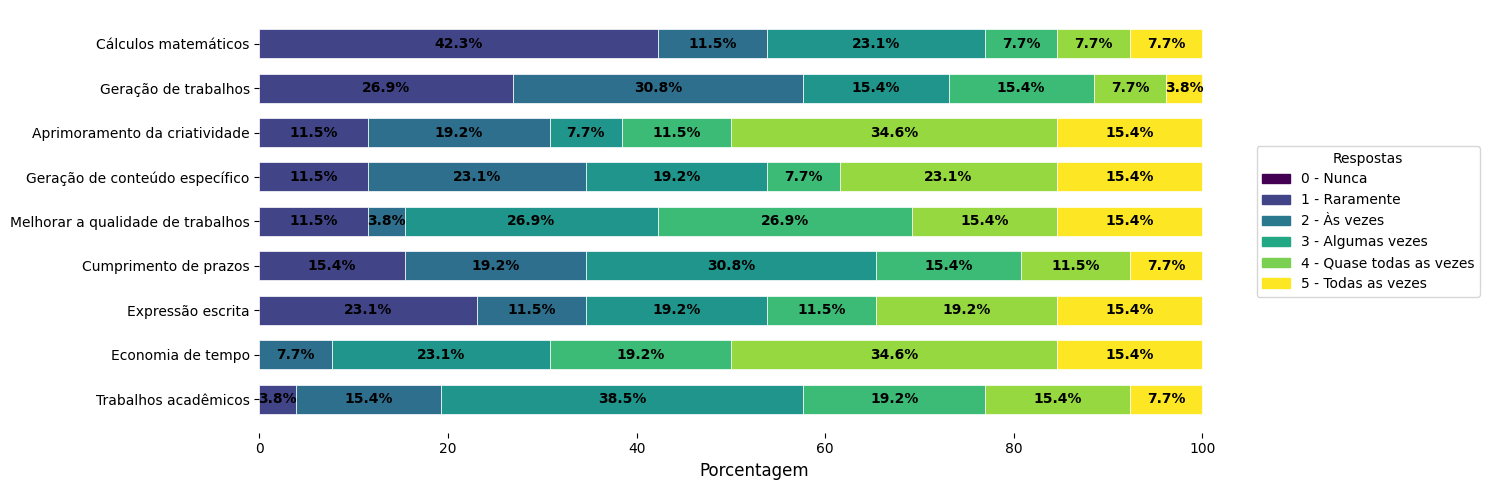

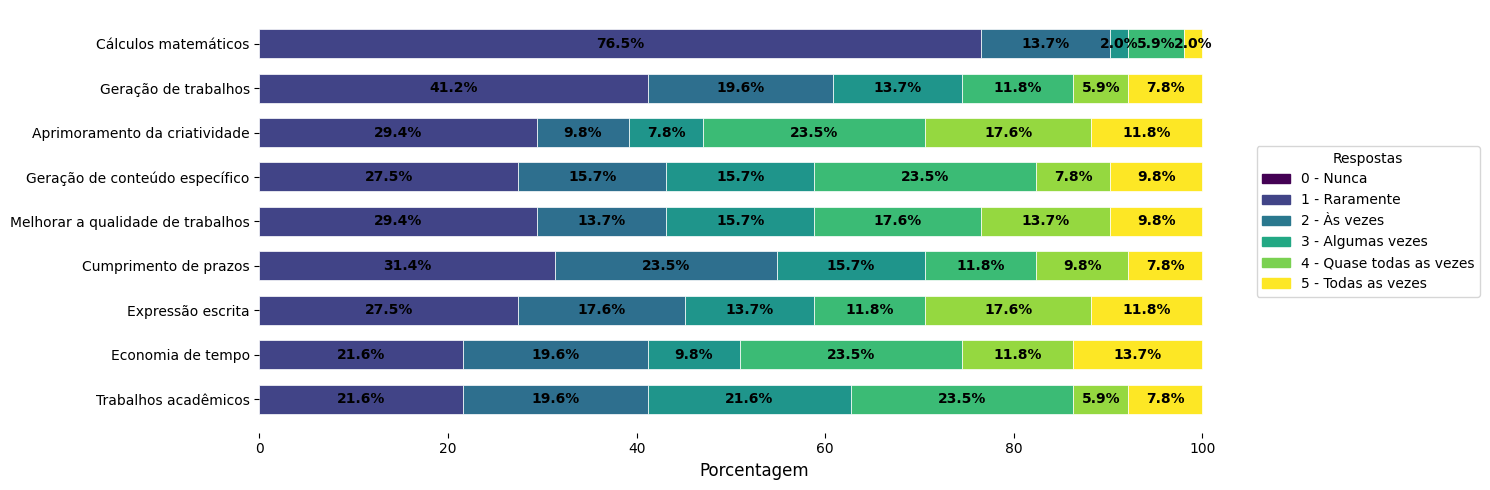

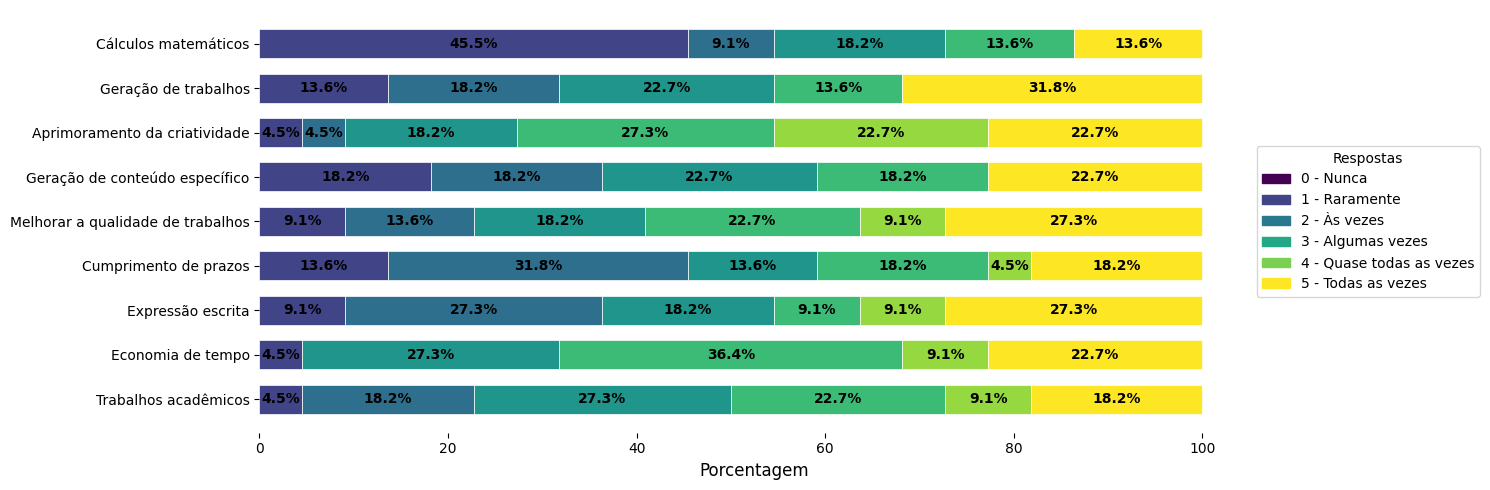

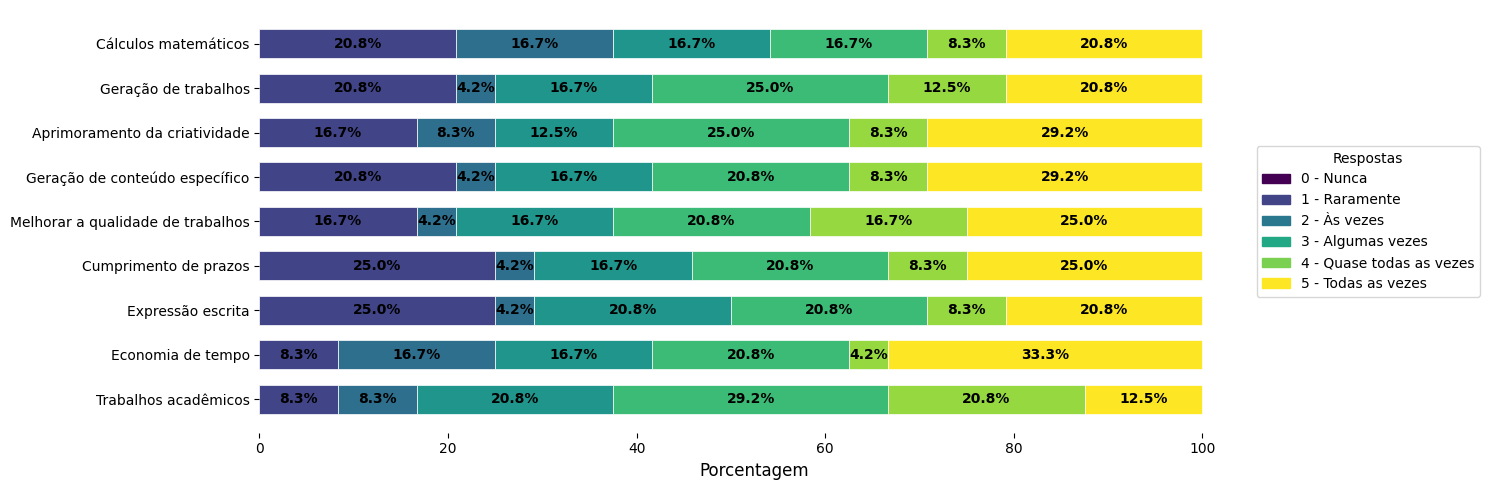


Dados do gráfico de frequência de uso de IA generativa em atividades:

Área: Ciências Exatas e da Terra
Com que frequência você utiliza alguma ferramenta de IA generativa na produção de textos acadêmicos/para trabalhos? De 0 à 5? (Sendo 0 para nenhuma vez e 5 todas as vezes): [np.float64(3.8461538461538463), np.float64(15.384615384615385), np.float64(38.46153846153847), np.float64(19.230769230769234), np.float64(15.384615384615385), np.float64(7.6923076923076925)]
Com que frequência você utiliza alguma ferramenta de IA generativa para economia de tempo de 0 à 5? (Sendo 0 para nenhuma vez e 5 todas as vezes): [0, np.float64(7.6923076923076925), np.float64(23.076923076923077), np.float64(19.230769230769234), np.float64(34.61538461538461), np.float64(15.384615384615385)]
Com que frequência você utiliza alguma ferramenta de IA generativa para ajudar na expressão escrita de 0 à 5? (Sendo 0 para nenhuma vez e 5 todas as vezes): [np.float64(23.076923076923077), np.float64(11.538461538461538)

In [220]:

# Seleciona as colunas cujos nomes começam com "Com que frequência"
perguntas_frequencia = df.filter(like="Com que frequência").columns
# Remover a última pergunta (se necessário, conforme seu comentário)
perguntas_frequencia = perguntas_frequencia[:-1]

# Lista com os nomes resumidos para exibição no eixo Y
perguntas = [
    "Trabalhos acadêmicos",
    "Economia de tempo",
    "Expressão escrita",
    "Cumprimento de prazos",
    "Melhorar a qualidade de trabalhos",
    "Geração de conteúdo específico",
    "Aprimoramento da criatividade",
    "Geração de trabalhos",
    "Cálculos matemáticos"
]

# Obtém as áreas únicas presentes na coluna "Área de Estudo Agrupada"
areas = df['Área de Estudo Agrupada'].unique()

# Loop para plotar um gráfico para cada área de estudo
for area in areas:
    # Subconjunto dos dados para a área atual
    df_area = df[df['Área de Estudo Agrupada'] == area]
    
    # Lista que armazenará as porcentagens de respostas para cada pergunta,
    # para a área atual
    respostas_por_pergunta = []
    
    # Para cada coluna de pergunta, calcule a porcentagem de respostas (0 a 5)
    for pergunta in perguntas_frequencia:
        # Conta as respostas (normalizado para porcentagem) e ordena pelo índice (0 a 5)
        contagem_respostas = df_area[pergunta].value_counts(normalize=True).sort_index() * 100
        # Garante que todos os valores de 0 a 5 estão presentes
        respostas = [contagem_respostas.get(i, 0) for i in range(6)]
        respostas_por_pergunta.append(respostas)
    
    # Cria o gráfico de barras horizontal empilhado para a área atual
    # usar paleta de cores viridis tirando o roxo
    cmap = cm.get_cmap('viridis')  # Paleta de cores viridis com 6 cores
    fig, ax = plt.subplots(figsize=(15, 5))
    
    # Plotar cada pergunta (cada linha no gráfico)
    for i, (pergunta_nome, respostas) in enumerate(zip(perguntas, respostas_por_pergunta)):
        acumulado = 0
        for j in range(6):
            # Ajusta o mapeamento para evitar tons muito escuros
            cor = cmap(0.2 + (j/5)*0.8)  # Remapeia o j para a faixa de 0.2 a 1.0
            ax.barh(
                pergunta_nome, 
                respostas[j], 
                left=acumulado, 
                color=cor,  # Normaliza o índice para o colormap viridis
                height=0.65, 
                edgecolor='white', 
                linewidth=0.5
            )
            acumulado += respostas[j]
    
    # Adiciona rótulos de porcentagem centralizados em cada fatia
    for i, (pergunta_nome, respostas) in enumerate(zip(perguntas, respostas_por_pergunta)):
        acumulado = 0
        for j in range(6):
            acumulado += respostas[j]
            if respostas[j] > 0:  # Adiciona rótulo somente se houver valor maior que 0
                ax.text(
                    acumulado - respostas[j] / 2, 
                    i, 
                    f'{respostas[j]:.1f}%', 
                    va='center', 
                    ha='center', 
                    color='black', 
                    fontweight='bold', 
                    fontsize=10
                )
    
    # Configurações dos eixos e título do gráfico
    ax.set_xlabel('Porcentagem', fontsize=12)
    # ax.set_title(f'Frequência de uso de IA generativa em atividades - {area}', fontsize=14)
    
    # Cria a legenda com os rótulos dos níveis de resposta (0 a 5)
    legenda_labels = ['0 - Nunca', '1 - Raramente', '2 - Às vezes', '3 - Algumas vezes', '4 - Quase todas as vezes', '5 - Todas as vezes']
    handles = [plt.Rectangle((0, 0), 1, 1, color=cmap(i / 5)) for i in range(6)]
    ax.legend(handles, legenda_labels, title="Respostas", loc='center left', bbox_to_anchor=(1, 0.5))
    
    # Ajusta o layout e exibe o gráfico
    plt.tight_layout()

    # Retira o box
    plt.box(False)
    plt.grid(False)

    plt.show()
    
    # Se desejar salvar a figura em uma pasta (descomente as linhas abaixo):
    # fig.savefig(f'figuras/grafico_frequencia_{area.replace(" ", "_")}.png', bbox_inches='tight', dpi=300)

# imprimir os dados do gráfico
print("\nDados do gráfico de frequência de uso de IA generativa em atividades:")
for area in areas:
    df_area = df[df['Área de Estudo Agrupada'] == area]
    print(f"\nÁrea: {area}")
    for pergunta in perguntas_frequencia:
        contagem_respostas = df_area[pergunta].value_counts(normalize=True).sort_index() * 100
        respostas = [contagem_respostas.get(i, 0) for i in range(6)]
        print(f"{pergunta}: {respostas}")

### Frequência de Verificação de Informações

C:\Users\Luise\AppData\Local\Temp\ipykernel_23136\418204310.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 6)


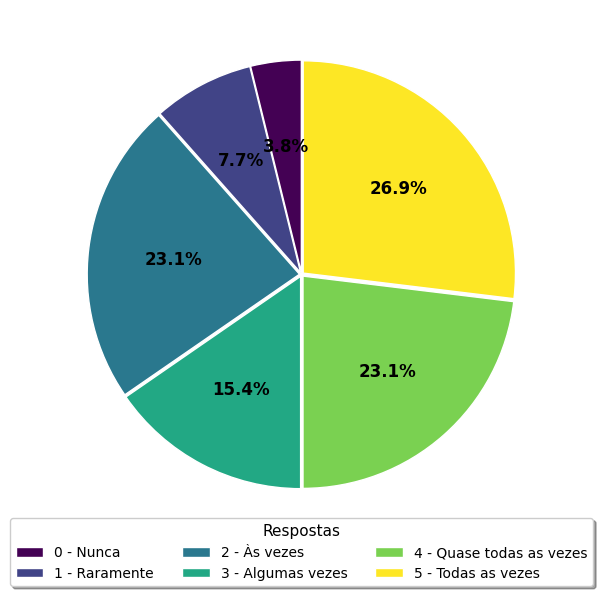

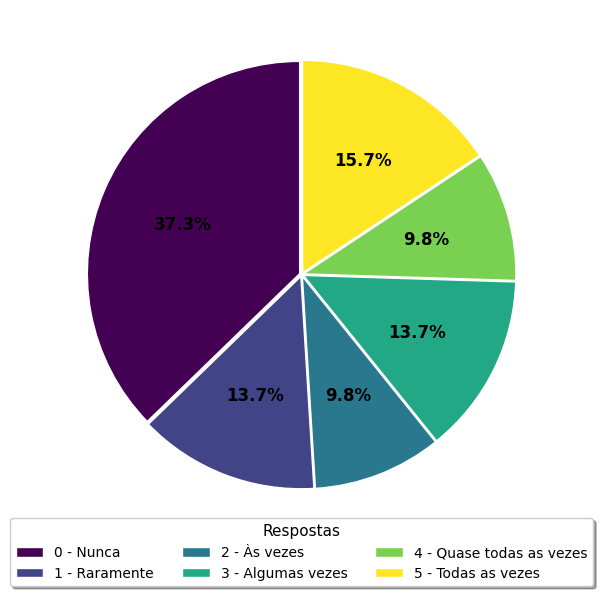

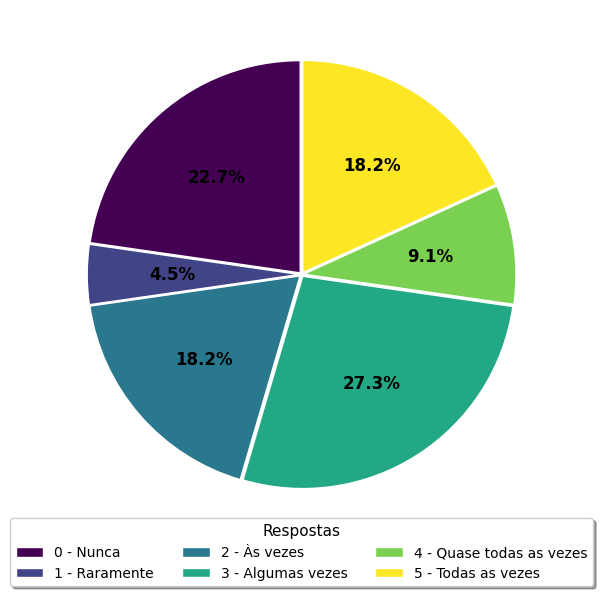

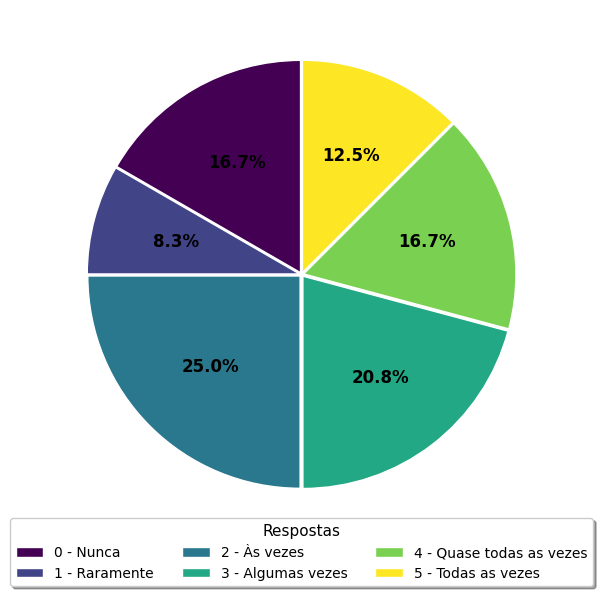


Dados do gráfico de verificação de informações geradas por IA:

Área: Ciências Exatas e da Terra
0 - Nunca: 3.8%
1 - Raramente: 7.7%
2 - Às vezes: 23.1%
3 - Algumas vezes: 15.4%
4 - Quase todas as vezes: 23.1%
5 - Todas as vezes: 26.9%

Área: Ciências Humanas e Sociais
0 - Nunca: 37.3%
1 - Raramente: 13.7%
2 - Às vezes: 9.8%
3 - Algumas vezes: 13.7%
4 - Quase todas as vezes: 9.8%
5 - Todas as vezes: 15.7%

Área: Ciências Biológicas
0 - Nunca: 22.7%
1 - Raramente: 4.5%
2 - Às vezes: 18.2%
3 - Algumas vezes: 27.3%
4 - Quase todas as vezes: 9.1%
5 - Todas as vezes: 18.2%

Área: Ciências Agrárias
0 - Nunca: 16.7%
1 - Raramente: 8.3%
2 - Às vezes: 25.0%
3 - Algumas vezes: 20.8%
4 - Quase todas as vezes: 16.7%
5 - Todas as vezes: 12.5%


In [230]:
# Nome da pergunta
pergunta_verificacao = "Com que frequência você verifica as informações geradas pelas ferramentas de IA generativa em outros sites de 0 à 5? (Sendo 0 para nenhuma vez e 5 todas as vezes)"

# Rótulos das respostas
labels = ['0 - Nunca', '1 - Raramente', '2 - Às vezes', '3 - Algumas vezes', '4 - Quase todas as vezes', '5 - Todas as vezes']

# Paleta de cores viridis (6 tons distribuídos)
cmap = cm.get_cmap('viridis', 6)
cores_viridis = [cmap(i / 5) for i in range(6)]

# Áreas únicas
areas = df['Área de Estudo Agrupada'].unique()

for area in areas:
    # Subconjunto dos dados da área
    df_area = df[df['Área de Estudo Agrupada'] == area]
    
    # Contagem de respostas normalizadas (em %)
    contagem_respostas = df_area[pergunta_verificacao].value_counts(normalize=True).sort_index() * 100
    
    # Garante que todos os valores de 0 a 5 estejam presentes
    respostas = [contagem_respostas.get(i, 0) for i in range(6)]
    
    # Criar gráfico de pizza
    fig, ax = plt.subplots(figsize=(7, 6))
    wedges, texts, autotexts = ax.pie(
        respostas,
        colors=cores_viridis,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'},
        explode=(0.01,) * len(respostas),
        wedgeprops={'edgecolor': 'white'}
    )
    
    # Título com o nome da área
    # ax.set_title(f'Verificação de informações por IA - {area}', fontsize=13)

    # Legenda ao lado com fancybox
    ax.legend(
        wedges,
        labels,
        title="Respostas",
        loc='lower center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=3,
        fontsize=10,
        title_fontsize=11,
        fancybox=True,
        shadow=True
    )
    
    plt.tight_layout()
    plt.show()

# Imprimir os dados do gráfico
print("\nDados do gráfico de verificação de informações geradas por IA:")
for area in areas:
    df_area = df[df['Área de Estudo Agrupada'] == area]
    contagem_respostas = df_area[pergunta_verificacao].value_counts(normalize=True).sort_index() * 100
    respostas = [contagem_respostas.get(i, 0) for i in range(6)]
    print(f"\nÁrea: {area}")
    for i, resposta in enumerate(respostas):
        print(f"{labels[i]}: {resposta:.1f}%")

### Ferramentas de IAG utilizadas

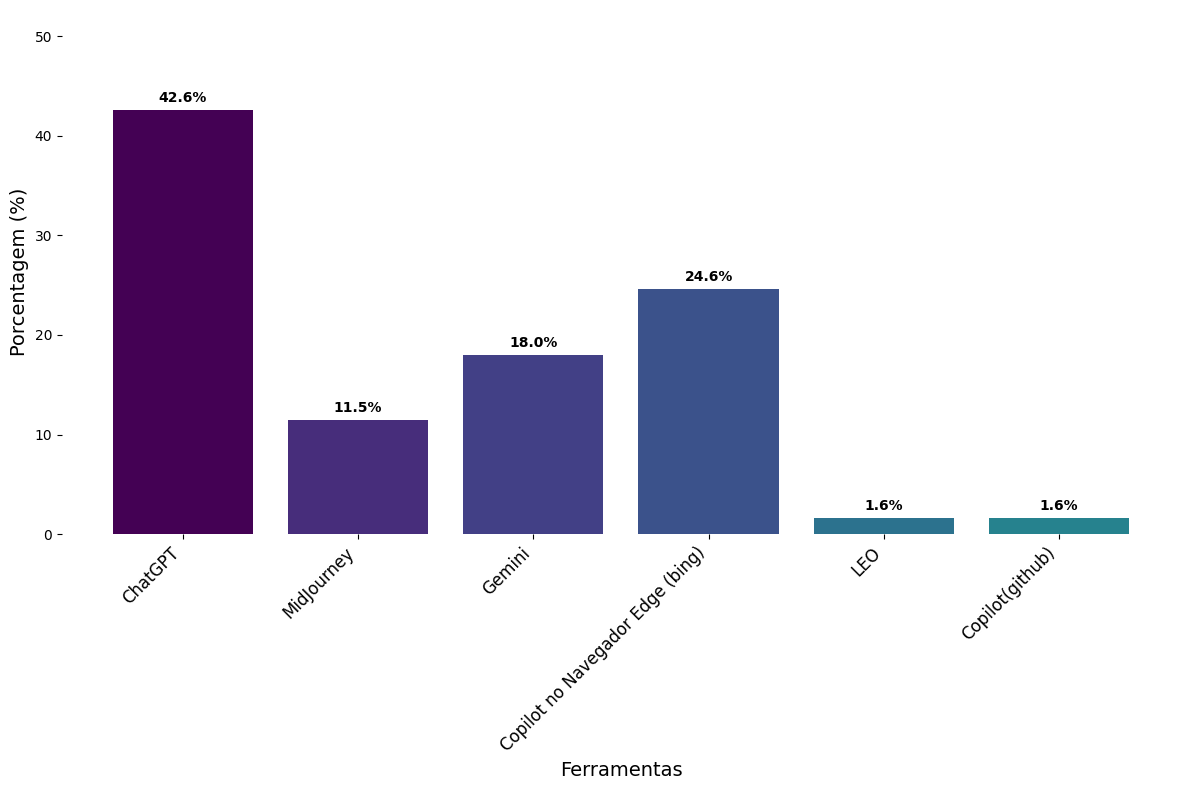


Contagem de ferramentas para Ciências Exatas e da Terra:
{'ChatGPT': 26, 'BERT': 0, 'MidJourney': 7, 'Gemini': 11, 'Copilot no Navegador Edge (bing)': 15, 'Nenhuma': 0, 'LEO': 1, 'Copilot(github)': 1, 'Youchat.com': 0, 'Perplexity': 0, 'SeaArt': 0, 'AssemblyAI': 0, 'Adobe Express': 0, 'AI Voice Generator': 0, 'Stockming AI': 0, 'Gamma': 0, 'Seowriting.ai': 0}

Porcentagem de ferramentas para Ciências Exatas e da Terra:
ChatGPT: 42.6%
MidJourney: 11.5%
Gemini: 18.0%
Copilot no Navegador Edge (bing): 24.6%
LEO: 1.6%
Copilot(github): 1.6%


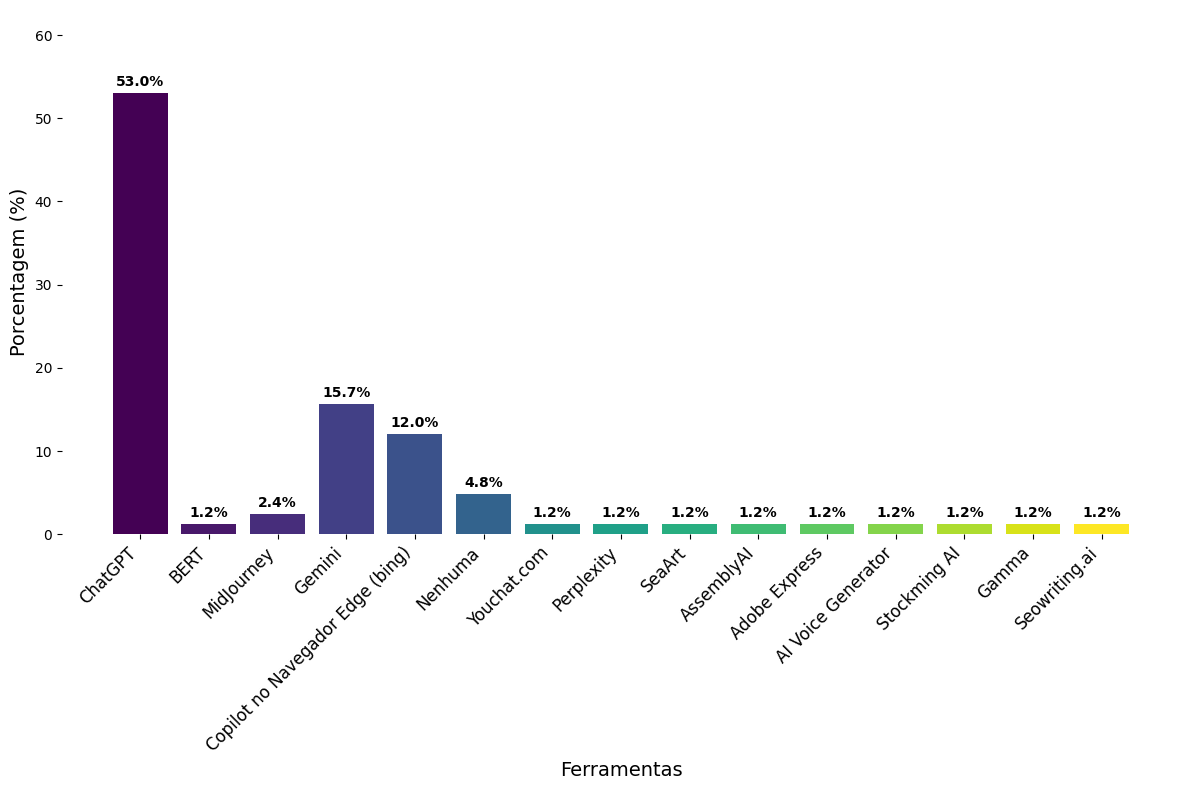


Contagem de ferramentas para Ciências Humanas e Sociais:
{'ChatGPT': 44, 'BERT': 1, 'MidJourney': 2, 'Gemini': 13, 'Copilot no Navegador Edge (bing)': 10, 'Nenhuma': 4, 'LEO': 0, 'Copilot(github)': 0, 'Youchat.com': 1, 'Perplexity': 1, 'SeaArt': 1, 'AssemblyAI': 1, 'Adobe Express': 1, 'AI Voice Generator': 1, 'Stockming AI': 1, 'Gamma': 1, 'Seowriting.ai': 1}

Porcentagem de ferramentas para Ciências Humanas e Sociais:
ChatGPT: 53.0%
BERT: 1.2%
MidJourney: 2.4%
Gemini: 15.7%
Copilot no Navegador Edge (bing): 12.0%
Nenhuma: 4.8%
Youchat.com: 1.2%
Perplexity: 1.2%
SeaArt: 1.2%
AssemblyAI: 1.2%
Adobe Express: 1.2%
AI Voice Generator: 1.2%
Stockming AI: 1.2%
Gamma: 1.2%
Seowriting.ai: 1.2%


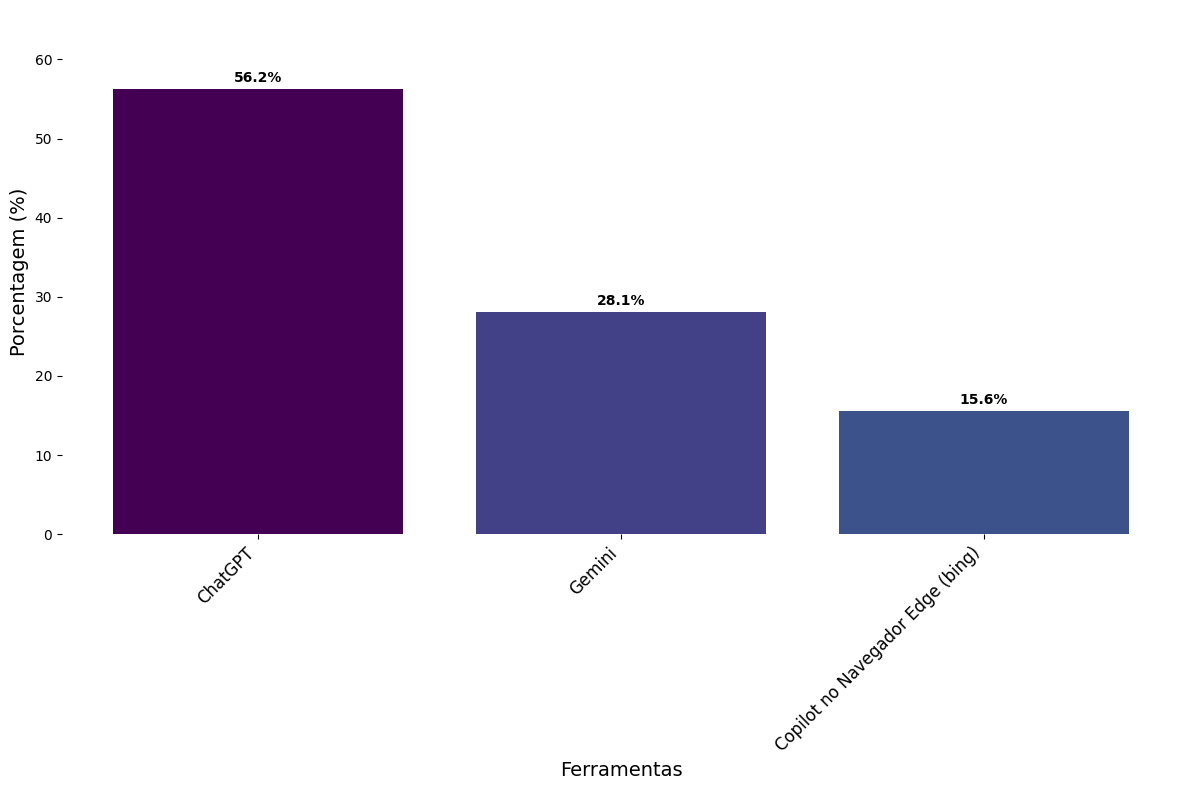


Contagem de ferramentas para Ciências Biológicas:
{'ChatGPT': 18, 'BERT': 0, 'MidJourney': 0, 'Gemini': 9, 'Copilot no Navegador Edge (bing)': 5, 'Nenhuma': 0, 'LEO': 0, 'Copilot(github)': 0, 'Youchat.com': 0, 'Perplexity': 0, 'SeaArt': 0, 'AssemblyAI': 0, 'Adobe Express': 0, 'AI Voice Generator': 0, 'Stockming AI': 0, 'Gamma': 0, 'Seowriting.ai': 0}

Porcentagem de ferramentas para Ciências Biológicas:
ChatGPT: 56.2%
Gemini: 28.1%
Copilot no Navegador Edge (bing): 15.6%


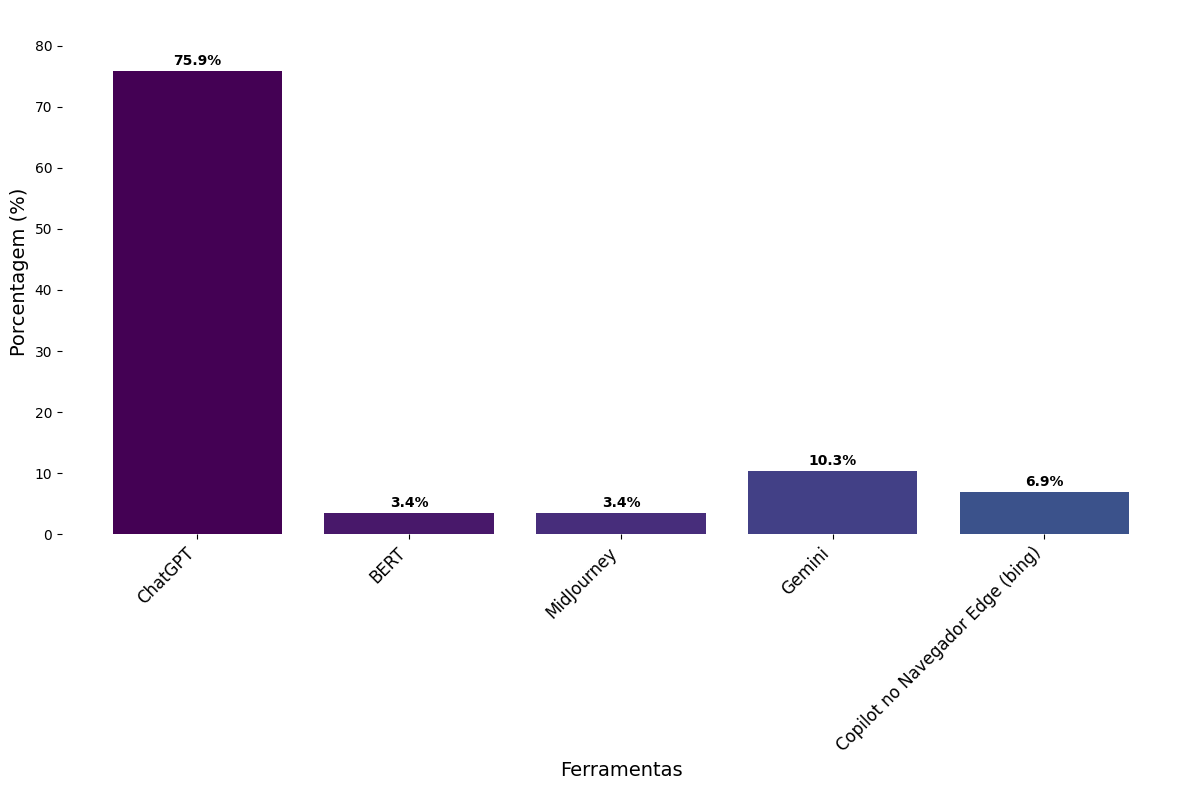


Contagem de ferramentas para Ciências Agrárias:
{'ChatGPT': 22, 'BERT': 1, 'MidJourney': 1, 'Gemini': 3, 'Copilot no Navegador Edge (bing)': 2, 'Nenhuma': 0, 'LEO': 0, 'Copilot(github)': 0, 'Youchat.com': 0, 'Perplexity': 0, 'SeaArt': 0, 'AssemblyAI': 0, 'Adobe Express': 0, 'AI Voice Generator': 0, 'Stockming AI': 0, 'Gamma': 0, 'Seowriting.ai': 0}

Porcentagem de ferramentas para Ciências Agrárias:
ChatGPT: 75.9%
BERT: 3.4%
MidJourney: 3.4%
Gemini: 10.3%
Copilot no Navegador Edge (bing): 6.9%


In [199]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Lista de ferramentas (estabelecida)
ferramentas = [
    "ChatGPT",
    "BERT",
    "MidJourney",
    "Gemini",
    "Copilot no Navegador Edge (bing)",
    "Nenhuma",
    "LEO",
    "Copilot(github)",
    "Youchat.com",
    "Perplexity",
    "SeaArt",
    "AssemblyAI",
    "Adobe Express",
    "AI Voice Generator",
    "Stockming AI",
    "Gamma",
    "Seowriting.ai"
]

# Função para normalizar strings: remove espaços extras e converte para minúsculas
def normalizar_ferramenta(ferramenta_str):
    return ferramenta_str.strip().lower()

# Definir as colunas de interesse: a resposta e a área de estudo agrupada
coluna_ferramentas = 'Cite quais as ferramentas de IA generativa você utiliza. (Marque todas que se aplicam)'
coluna_area = 'Área de Estudo Agrupada'

# Obter as áreas de estudo, excluindo valores nulos
areas_estudo = df[coluna_area].dropna().unique()

# Criar uma paleta de cores global para todas as ferramentas, garantindo que cada ferramenta tenha a mesma cor
global_colors_array = plt.cm.viridis(np.linspace(0, 1, len(ferramentas)))
global_colors = {ferramenta: color for ferramenta, color in zip(ferramentas, global_colors_array)}

# Loop para cada área de estudo; para cada uma, gerar um gráfico de barras verticais
for area in areas_estudo:
    # Filtrar os dados para a área
    df_area = df[df[coluna_area] == area]
    
    # Inicializar contagem de cada ferramenta para a área
    contagem_ferramentas = {ferramenta: 0 for ferramenta in ferramentas}
    
    # Processar as respostas (assumindo que as respostas são separadas por vírgula)
    for resposta in df_area[coluna_ferramentas].dropna():
        ferramentas_resposta = [normalizar_ferramenta(f) for f in resposta.split(',')]
        for ferramenta in ferramentas_resposta:
            # Se a resposta indicar "nenhuma" ou variações similares, agrupar em "Nenhuma"
            if any(termo in ferramenta for termo in ["nenhuma", "não uso", "não utilizei", "não utilizo"]):
                contagem_ferramentas["Nenhuma"] += 1
            else:
                for key in contagem_ferramentas.keys():
                    if normalizar_ferramenta(key) == ferramenta:
                        contagem_ferramentas[key] += 1
                        break
    
    # Preparar os dados para o gráfico, mantendo a ordem definida em "ferramentas"
    contagens = [contagem_ferramentas[ferramenta] for ferramenta in ferramentas]
    total_respostas = sum(contagens)
    # Calcular as porcentagens – se total_respostas for 0, todas serão 0
    porcentagens = [(count / total_respostas) * 100 if total_respostas > 0 else 0 for count in contagens]
    
    # Filtrar os dados: manter apenas as ferramentas com porcentagem maior que 0
    ferramentas_filtradas = [f for f, pct in zip(ferramentas, porcentagens) if pct > 0]
    porcentagens_filtradas = [pct for pct in porcentagens if pct > 0]
    cores_filtradas = [global_colors[f] for f, pct in zip(ferramentas, porcentagens) if pct > 0]
    
    # Verifica se há algum dado para plotar
    if not ferramentas_filtradas:
        print(f"\nNenhuma ferramenta reportada com porcentagem > 0 para {area}.")
        continue
    
    # Criar gráfico de barras verticais
    plt.figure(figsize=(12, 8))
    x = np.arange(len(ferramentas_filtradas))
    bars = plt.bar(x, porcentagens_filtradas, color=cores_filtradas)
    plt.xlabel('Ferramentas', fontsize=14)
    plt.ylabel('Porcentagem (%)', fontsize=14)
    # plt.title(f'Ferramentas de IA Generativa – {area}', fontsize=16)
    
    # Configurar os rótulos do eixo X para mostrar os nomes das ferramentas filtradas
    plt.xticks(x, ferramentas_filtradas, rotation=45, ha="right", fontsize=12)
    
    # Adicionar rótulos acima das barras (apenas para barras com porcentagem > 0; aqui já foram filtradas)
    for bar, pct in zip(bars, porcentagens_filtradas):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{pct:.1f}%', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.ylim(0, max(porcentagens_filtradas) + 10)
    plt.grid(False)
    plt.box(False)
    plt.tight_layout()
    plt.show()
    
    # Imprimir a contagem para referência
    print(f"\nContagem de ferramentas para {area}:")
    print(contagem_ferramentas)

    # porcentagens:
    print(f"\nPorcentagem de ferramentas para {area}:")
    for ferramenta, porcentagem in zip(ferramentas_filtradas, porcentagens_filtradas):
        print(f"{ferramenta}: {porcentagem:.1f}%")


### Prazos Apertados

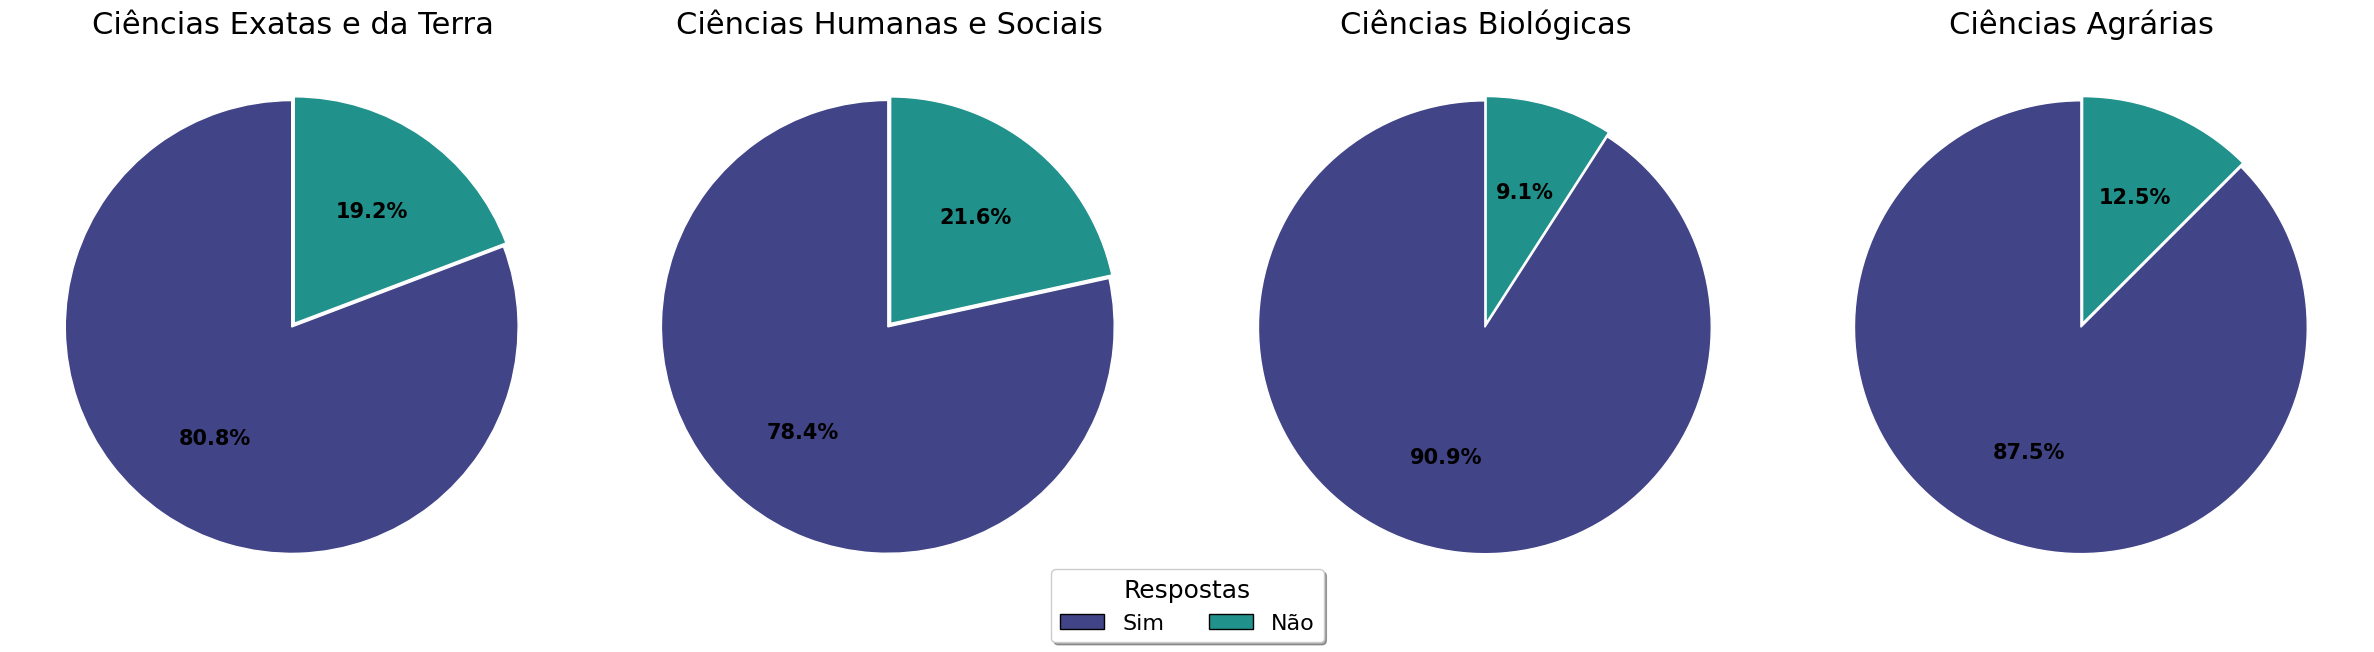


Dados do gráfico de prazos apertados:

Área: Ciências Exatas e da Terra
Sim: 80.8%
Não: 19.2%

Área: Ciências Humanas e Sociais
Sim: 78.4%
Não: 21.6%

Área: Ciências Biológicas
Sim: 90.9%
Não: 9.1%

Área: Ciências Agrárias
Sim: 87.5%
Não: 12.5%


In [236]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

coluna_prazos_apertados = 'Em situações de prazos apertados, a IA generativa é uma escolha para atender a essas demandas?'
coluna_area = 'Área de Estudo Agrupada'

cores = plt.cm.viridis([0.2, 0.5])
areas_estudo = df[coluna_area].dropna().unique()

fig, axes = plt.subplots(1, len(areas_estudo), figsize=(6 * len(areas_estudo), 6))

# Se tiver só 1 gráfico, axes não é uma lista
if len(areas_estudo) == 1:
    axes = [axes]

for ax, area in zip(axes, areas_estudo):
    df_area = df[df[coluna_area] == area]
    respostas_prazos = df_area[coluna_prazos_apertados].value_counts(normalize=True) * 100

    if respostas_prazos.empty:
        ax.axis('off')
        continue

    wedges, texts, autotexts = ax.pie(
        respostas_prazos, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=cores[:len(respostas_prazos)],
        textprops={'fontsize': 15, 'fontweight': 'bold'},
        explode=(0.01,) * len(respostas_prazos),
        wedgeprops={'edgecolor': 'white'}
    )

    ax.set_title(f'{area}', fontsize=22)

# Criar legenda global
legend_elements = [
    Patch(facecolor=cores[i], label=respostas_prazos.index[i], edgecolor='black') 
    for i in range(len(respostas_prazos))
]
fig.legend(
    handles=legend_elements, 
    title='Respostas', 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.05), 
    ncol=2, 
    fancybox=True, 
    shadow=True, 
    fontsize=16,
    title_fontsize=18
)

plt.tight_layout()
plt.show()

# imprimir os dados do gráfico
print("\nDados do gráfico de prazos apertados:")
for area in areas_estudo:
    df_area = df[df[coluna_area] == area]
    respostas_prazos = df_area[coluna_prazos_apertados].value_counts(normalize=True) * 100
    print(f"\nÁrea: {area}")
    for resposta, porcentagem in respostas_prazos.items():
        print(f"{resposta}: {porcentagem:.1f}%")

### Interação com IAG (Categorização se é bom, ruim ou neutra)

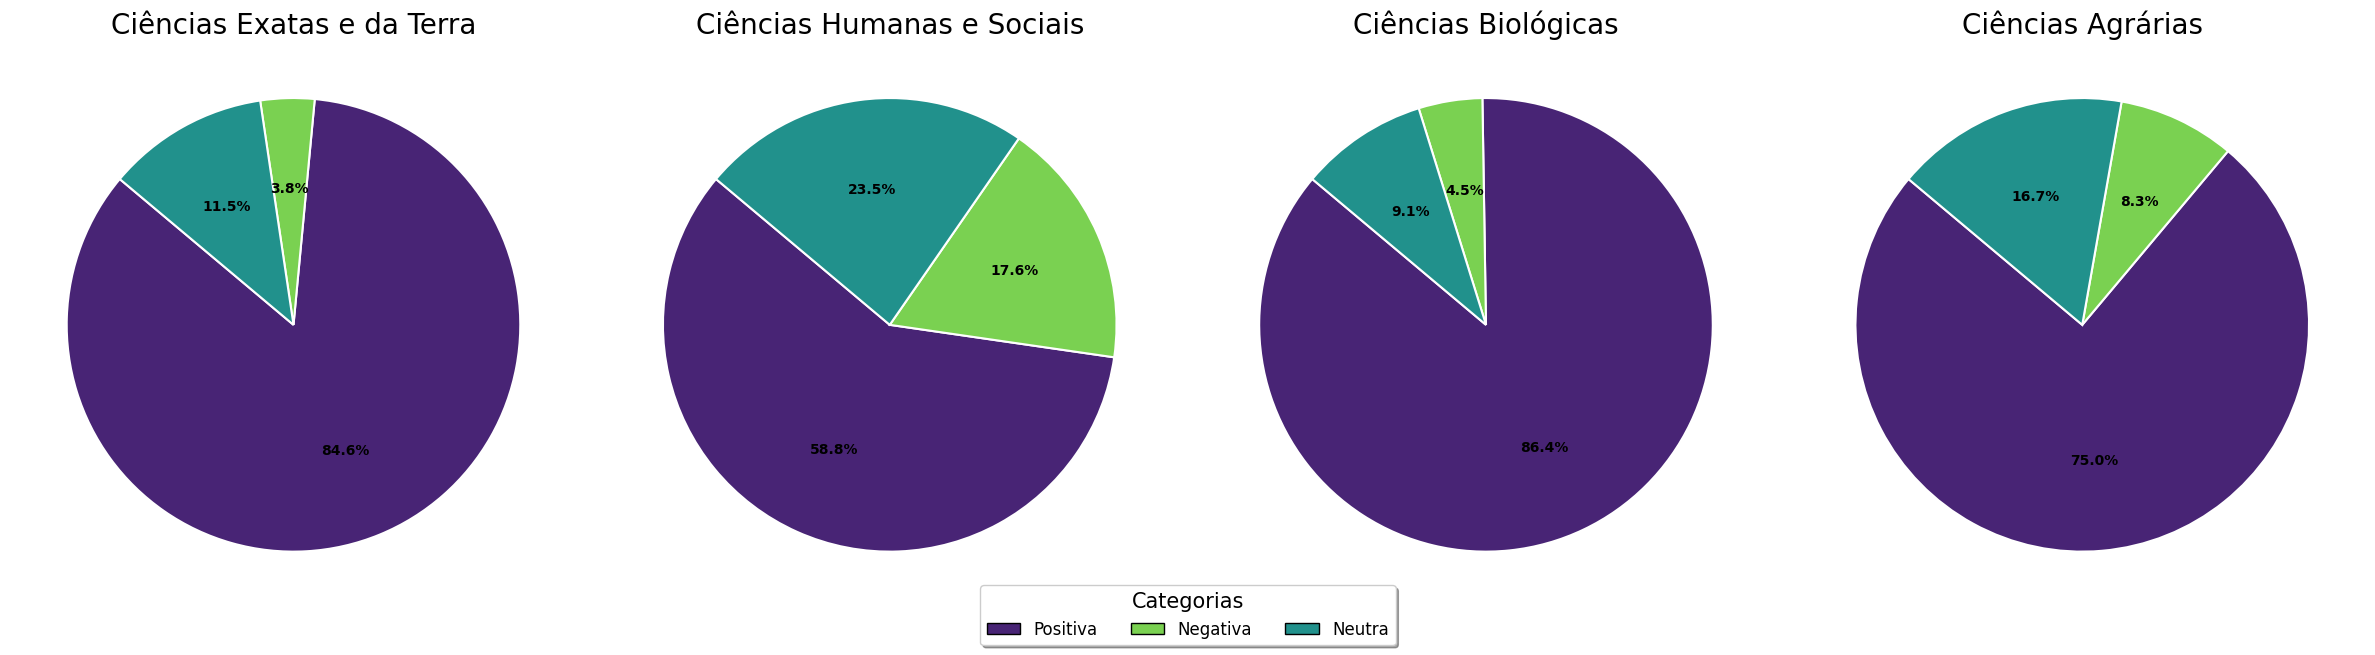

In [174]:
# Normaliza as respostas para facilitar a categorização
df['respostas'] = df['Você considera a interação IA e acadêmicos positiva, negativa ou neutra? Por quê?'].str.lower().str.strip()
coluna_area = 'Área de Estudo Agrupada'

# Define cores fixas para consistência entre gráficos
cores = {
    'positiva': plt.cm.viridis(0.1),
    'negativa': plt.cm.viridis(0.8),
    'neutra': plt.cm.viridis(0.5)
}

categorias = ['positiva', 'negativa', 'neutra']
areas = df[coluna_area].dropna().unique()

# Criação da figura com 1 linha e 4 colunas
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Se tiver menos de 4 áreas, preencher com gráficos vazios
for i in range(len(axes)):
    if i >= len(areas):
        axes[i].axis('off')

# Função auxiliar para categorizar
def classificar_resposta(texto):
    if pd.isna(texto): return 'neutra'
    texto = texto.lower()
    if any(p in texto for p in ['positiva', 'ajuda', 'útil', 'importante', 'apoio', 'facilitador', 'melhor', 'esclarece', 'auxilia']):
        return 'positiva'
    elif any(n in texto for n in ['negativa', 'prejudica', 'perde', 'diminui', 'limita', 'descreve', 'desinteresse', 'burrice', 'cola', 'não', 'mau', 'difícil']):
        return 'negativa'
    elif any(n in texto for n in ['neutra', 'depende', 'não sei', 'sem opinião', 'não utilizo']):
        return 'neutra'
    else:
        return 'neutra'

# Aplica a classificação
df['classificacao'] = df['respostas'].apply(classificar_resposta)

# Plot por área
for i, area in enumerate(areas):
    df_area = df[df[coluna_area] == area]
    contagem = df_area['classificacao'].value_counts()
    porcentagens = {key: (contagem.get(key, 0) / len(df_area)) * 100 for key in categorias}
    sizes = list(contagem.get(cat, 0) for cat in categorias)
    
    ax = axes[i]
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=None,
        colors=[cores[cat] for cat in categorias],
        autopct='%1.1f%%',
        startangle=140,
        textprops=dict(color='white'),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )

    ax.set_title(f'{area}', fontsize=20)

    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_color('black')
        autotext.set_fontweight('bold')

# Legenda global
legend_elements = [Patch(facecolor=cores[cat], label=cat.capitalize(), edgecolor='black') for cat in categorias]
fig.legend(
    handles=legend_elements,
    title='Categorias',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    fancybox=True,
    shadow=True,
    fontsize=12,
    title_fontsize=15
)

plt.tight_layout()
plt.show()


### Familiaridade com IAG

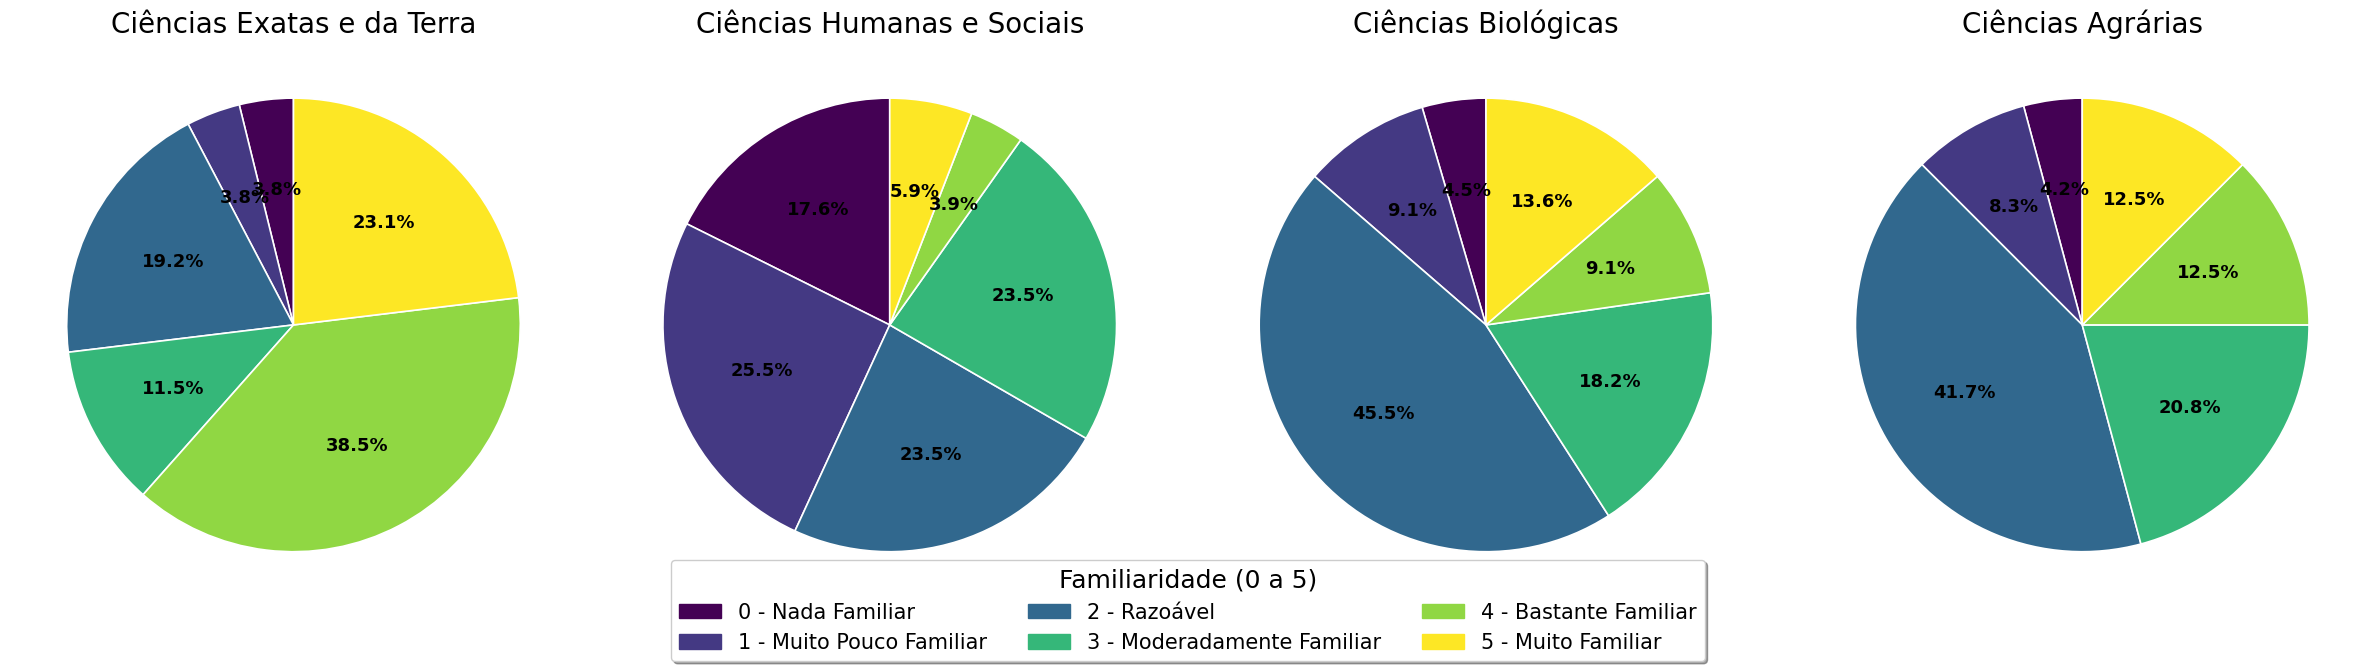


Dados do gráfico de familiaridade com IA generativa:

Área: Ciências Exatas e da Terra
0 - Nada Familiar: 4.2%
1 - Muito Pouco Familiar: 8.3%
2 - Razoável: 41.7%
3 - Moderadamente Familiar: 20.8%
4 - Bastante Familiar: 12.5%
5 - Muito Familiar: 12.5%

Área: Ciências Humanas e Sociais
0 - Nada Familiar: 4.2%
1 - Muito Pouco Familiar: 8.3%
2 - Razoável: 41.7%
3 - Moderadamente Familiar: 20.8%
4 - Bastante Familiar: 12.5%
5 - Muito Familiar: 12.5%

Área: Ciências Biológicas
0 - Nada Familiar: 4.2%
1 - Muito Pouco Familiar: 8.3%
2 - Razoável: 41.7%
3 - Moderadamente Familiar: 20.8%
4 - Bastante Familiar: 12.5%
5 - Muito Familiar: 12.5%

Área: Ciências Agrárias
0 - Nada Familiar: 4.2%
1 - Muito Pouco Familiar: 8.3%
2 - Razoável: 41.7%
3 - Moderadamente Familiar: 20.8%
4 - Bastante Familiar: 12.5%
5 - Muito Familiar: 12.5%


In [237]:
# Pergunta sobre familiaridade
pergunta_familiaridade = "Quão familiar você se considera com as capacidades da IA generativa? (0 para pouco e 5 para muito)"
coluna_area = 'Área de Estudo Agrupada'

# Nomenclatura das respostas
nomenclaturas = ['0 - Nada Familiar', '1 - Muito Pouco Familiar', '2 - Razoável', 
                 '3 - Moderadamente Familiar', '4 - Bastante Familiar', '5 - Muito Familiar']

# Cores com colormap viridis
cmap = plt.get_cmap('viridis', 7)
cores = cmap(np.linspace(0, 1, 6))

# Áreas únicas
areas = df[coluna_area].dropna().unique()

# Criar subplots lado a lado
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Loop pelas áreas
for i, area in enumerate(areas):
    if i >= 4:
        break  # Apenas até 4 áreas

    ax = axes[i]
    df_area = df[df[coluna_area] == area]

    # Contagem de respostas de 0 a 5, normalizada
    contagem_respostas = df_area[pergunta_familiaridade].value_counts(normalize=True).sort_index() * 100
    respostas = [contagem_respostas.get(i, 0) for i in range(6)]

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(respostas, labels=None, colors=cores, autopct='%1.1f%%',
                                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
                                      textprops=dict(color="black", fontweight='bold', fontsize=13))

    ax.set_title(f'{area}', fontsize=20)  # Sem negrito

# Legenda única para todos
legend_elements = [Patch(color=cores[i], label=nomenclaturas[i]) for i in range(6)]
fig.legend(handles=legend_elements, title='Familiaridade (0 a 5)', loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=3, fancybox=True, shadow=True, fontsize=15, title_fontsize=18)

plt.tight_layout()
plt.show()

# imprimir os dados do gráfico
print("\nDados do gráfico de familiaridade com IA generativa:")
for area in areas:
    df_area = df[df[coluna_area] == area]
    contagem_respostas = df_area[pergunta_familiaridade].value_counts(normalize=True).sort_index() * 100
    print(f"\nÁrea: {area}")
    for i, resposta in enumerate(respostas):
        print(f"{nomenclaturas[i]}: {resposta:.1f}%")

### Comprometimento da Autenticidade ao Utilizar IA Generativa

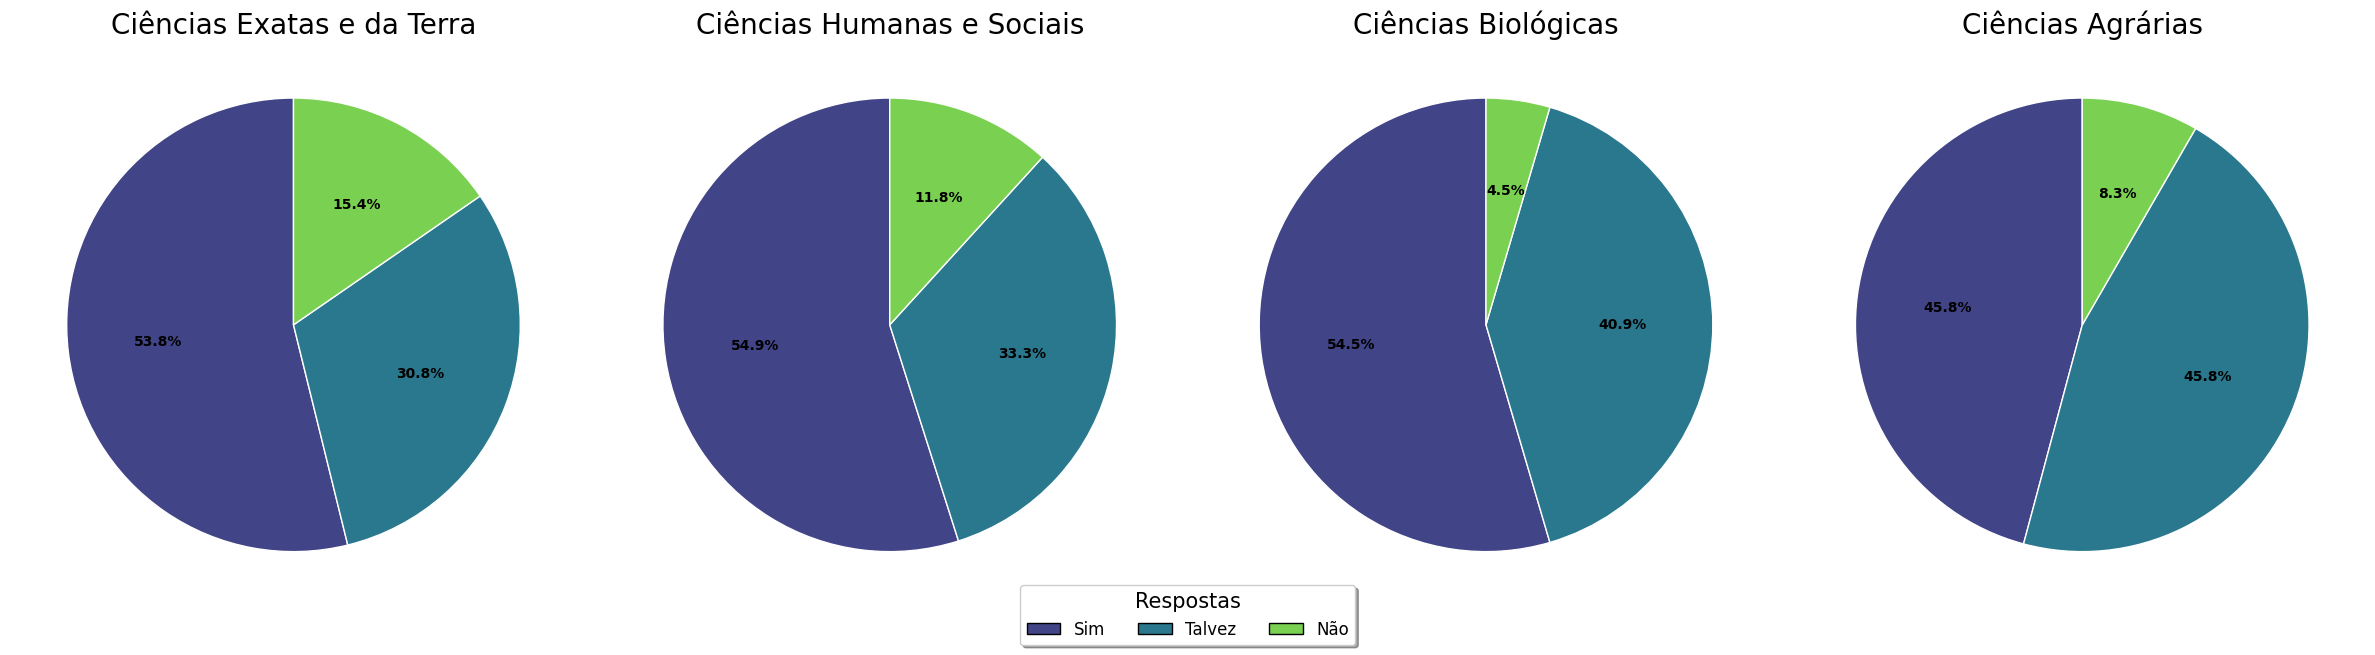


Dados do gráfico de autenticidade:

Área: Ciências Exatas e da Terra
Talvez: 53.8%
Sim: 30.8%
Não: 15.4%

Área: Ciências Humanas e Sociais
Sim: 54.9%
Talvez: 33.3%
Não: 11.8%

Área: Ciências Biológicas
Sim: 54.5%
Talvez: 40.9%
Não: 4.5%

Área: Ciências Agrárias
Sim: 45.8%
Talvez: 45.8%
Não: 8.3%


In [238]:
# Coluna com a pergunta sobre autenticidade
coluna_autenticidade = 'Você acredita que o uso da IA generativa pode comprometer a autenticidade do seu trabalho acadêmico?'
coluna_area = 'Área de Estudo Agrupada'

# Paleta de cores
cores = plt.cm.viridis([0.2, 0.4, 0.8])  # Ajustável conforme o número de categorias

# Áreas únicas
areas = df[coluna_area].dropna().unique()

# Criar subplots
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Loop pelas áreas
for i, area in enumerate(areas):
    if i >= 4:
        break  # Limita a 4 áreas

    ax = axes[i]
    df_area = df[df[coluna_area] == area]

    # Contagem das respostas
    contagem_respostas = df_area[coluna_autenticidade].value_counts()
    labels = contagem_respostas.index.tolist()
    sizes = contagem_respostas.values.tolist()

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(sizes, labels=None, colors=cores[:len(sizes)], autopct='%1.1f%%',
                                      wedgeprops=dict(edgecolor='white'), startangle=90,
                                      textprops=dict(color='black', fontweight='bold'))

    ax.set_title(f'{area}', fontsize=20)  # Sem negrito

# Legenda única
legend_elements = [Patch(facecolor=cores[i], edgecolor='black', label=labels[i]) for i in range(len(labels))]
fig.legend(handles=legend_elements, title="Respostas", loc="lower center",
           bbox_to_anchor=(0.5, -0.05), ncol=3, fancybox=True, shadow=True, fontsize=12, title_fontsize=15)

plt.tight_layout()
plt.show()

# imprimir os dados do gráfico
print("\nDados do gráfico de autenticidade:")
for area in areas:
    df_area = df[df[coluna_area] == area]
    contagem_respostas = df_area[coluna_autenticidade].value_counts(normalize=True) * 100
    print(f"\nÁrea: {area}")
    for resposta, porcentagem in contagem_respostas.items():
        print(f"{resposta}: {porcentagem:.1f}%")

### Pergunta Aberta sobre os motivos de IAG ser eficiente em atividades acadêmicas

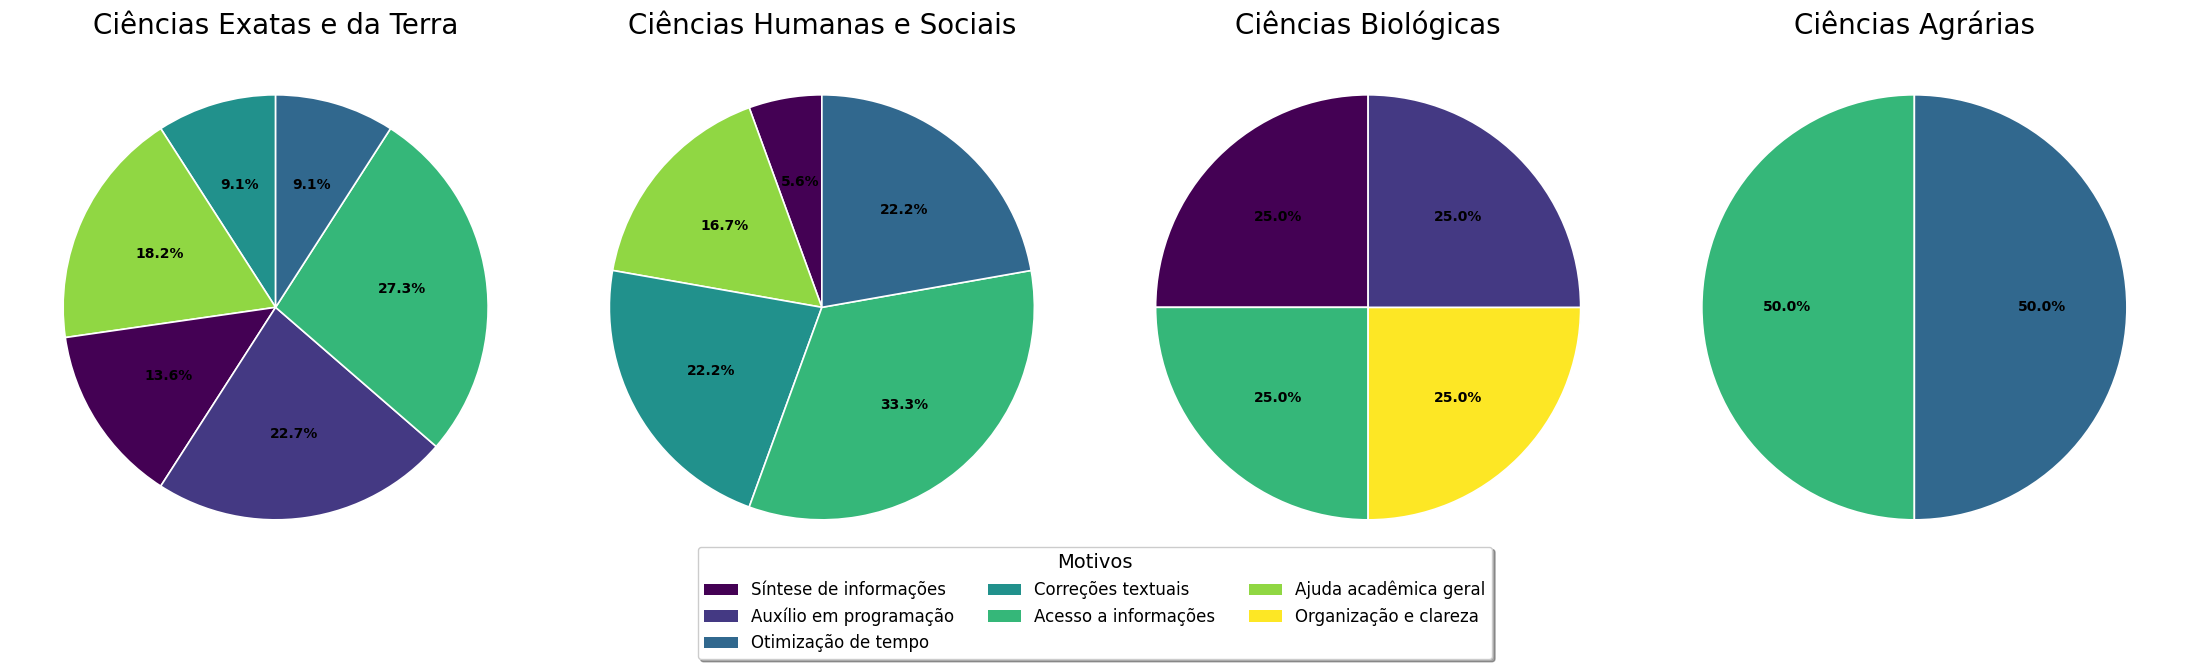


Dados do gráfico de eficiência da IA generativa:

Área: Ciências Exatas e da Terra
Correções textuais: 2 (9.5%)
Ajuda acadêmica geral: 4 (19.0%)
Síntese de informações: 3 (14.3%)
Auxílio em programação: 5 (23.8%)
Acesso a informações: 6 (28.6%)
Otimização de tempo: 2 (9.5%)

Área: Ciências Humanas e Sociais
Síntese de informações: 1 (3.6%)
Ajuda acadêmica geral: 3 (10.7%)
Correções textuais: 4 (14.3%)
Acesso a informações: 6 (21.4%)
Otimização de tempo: 4 (14.3%)

Área: Ciências Biológicas
Síntese de informações: 1 (7.7%)
Acesso a informações: 1 (7.7%)
Organização e clareza: 1 (7.7%)
Auxílio em programação: 1 (7.7%)

Área: Ciências Agrárias
Acesso a informações: 1 (7.1%)
Otimização de tempo: 1 (7.1%)


In [239]:
from collections import Counter

# Pergunta de interesse
coluna_resposta = 'Se sim, por que você considera a IA generativa eficiente em suas atividades acadêmicas?'
coluna_area = 'Área de Estudo Agrupada'

# Palavras-chave
palavras_chave = {
    'Síntese de informações': ['sintetizar', 'sintetiza', 'resumo', 'resumir', 'agrega'],
    'Auxílio em programação': ['código', 'programação', 'codificação', 'debug', 'bugs', 'copilot'],
    'Otimização de tempo': ['tempo', 'agilidade', 'produtividade'],
    'Correções textuais': ['texto', 'gramatical', 'correção', 'escrita'],
    'Acesso a informações': ['informações', 'conteúdo', 'dados', 'conhecimento'],
    'Ajuda acadêmica geral': ['acadêmico', 'estudo', 'aprendizado', 'pesquisa'],
    'Organização e clareza': ['organizar', 'estruturar', 'clareza', 'estruturado'],
}

# Função para categorizar respostas
def categorizar_respostas(respostas, palavras_chave):
    categorias_contagem = Counter()
    for resposta in respostas:
        for categoria, palavras in palavras_chave.items():
            if any(palavra in resposta.lower() for palavra in palavras):
                categorias_contagem[categoria] += 1
    return categorias_contagem

# Obter áreas únicas
areas_estudo = df[coluna_area].dropna().unique()

# Criar subplots
fig, axes = plt.subplots(1, len(areas_estudo), figsize=(22, 6))

# Paleta de cores
cores_base = plt.cm.viridis(np.linspace(0, 1, len(palavras_chave)))

for ax, area in zip(axes, areas_estudo):
    # Filtrar dados
    respostas_area = df[df[coluna_area] == area][coluna_resposta].dropna()
    
    # Categorizar
    contagem_area = categorizar_respostas(respostas_area, palavras_chave)

    if not contagem_area:
        ax.axis('off')
        continue

    # Preparar dados para plot
    categorias = list(contagem_area.keys())
    valores = list(contagem_area.values())
    cores = [cores_base[list(palavras_chave.keys()).index(cat)] for cat in categorias]

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(
        valores,
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
        textprops={'fontsize': 10, 'color': 'black', 'fontweight': 'bold'}
    )

    # Título da área
    ax.set_title(area, fontsize=20)

# Legenda global
legend_labels = list(palavras_chave.keys())
legend_colors = [Patch(facecolor=cores_base[i], label=legend_labels[i]) for i in range(len(legend_labels))]
fig.legend(
    handles=legend_colors,
    labels=legend_labels,
    title="Motivos", 
    loc="lower center", 
    bbox_to_anchor=(0.5, -0.1), 
    ncol=3, 
    fontsize=12,
    title_fontsize=14,
    fancybox=True,
    shadow=True
    )

# Layout
plt.tight_layout()
plt.show()

# imprimir os dados do gráfico
print("\nDados do gráfico de eficiência da IA generativa:")
for area in areas_estudo:
    respostas_area = df[df[coluna_area] == area][coluna_resposta].dropna()
    contagem_area = categorizar_respostas(respostas_area, palavras_chave)
    print(f"\nÁrea: {area}")
    for categoria, contagem in contagem_area.items():
        print(f"{categoria}: {contagem} ({(contagem / len(respostas_area)) * 100:.1f}%)")

### IA versus Métodos Tradicionais

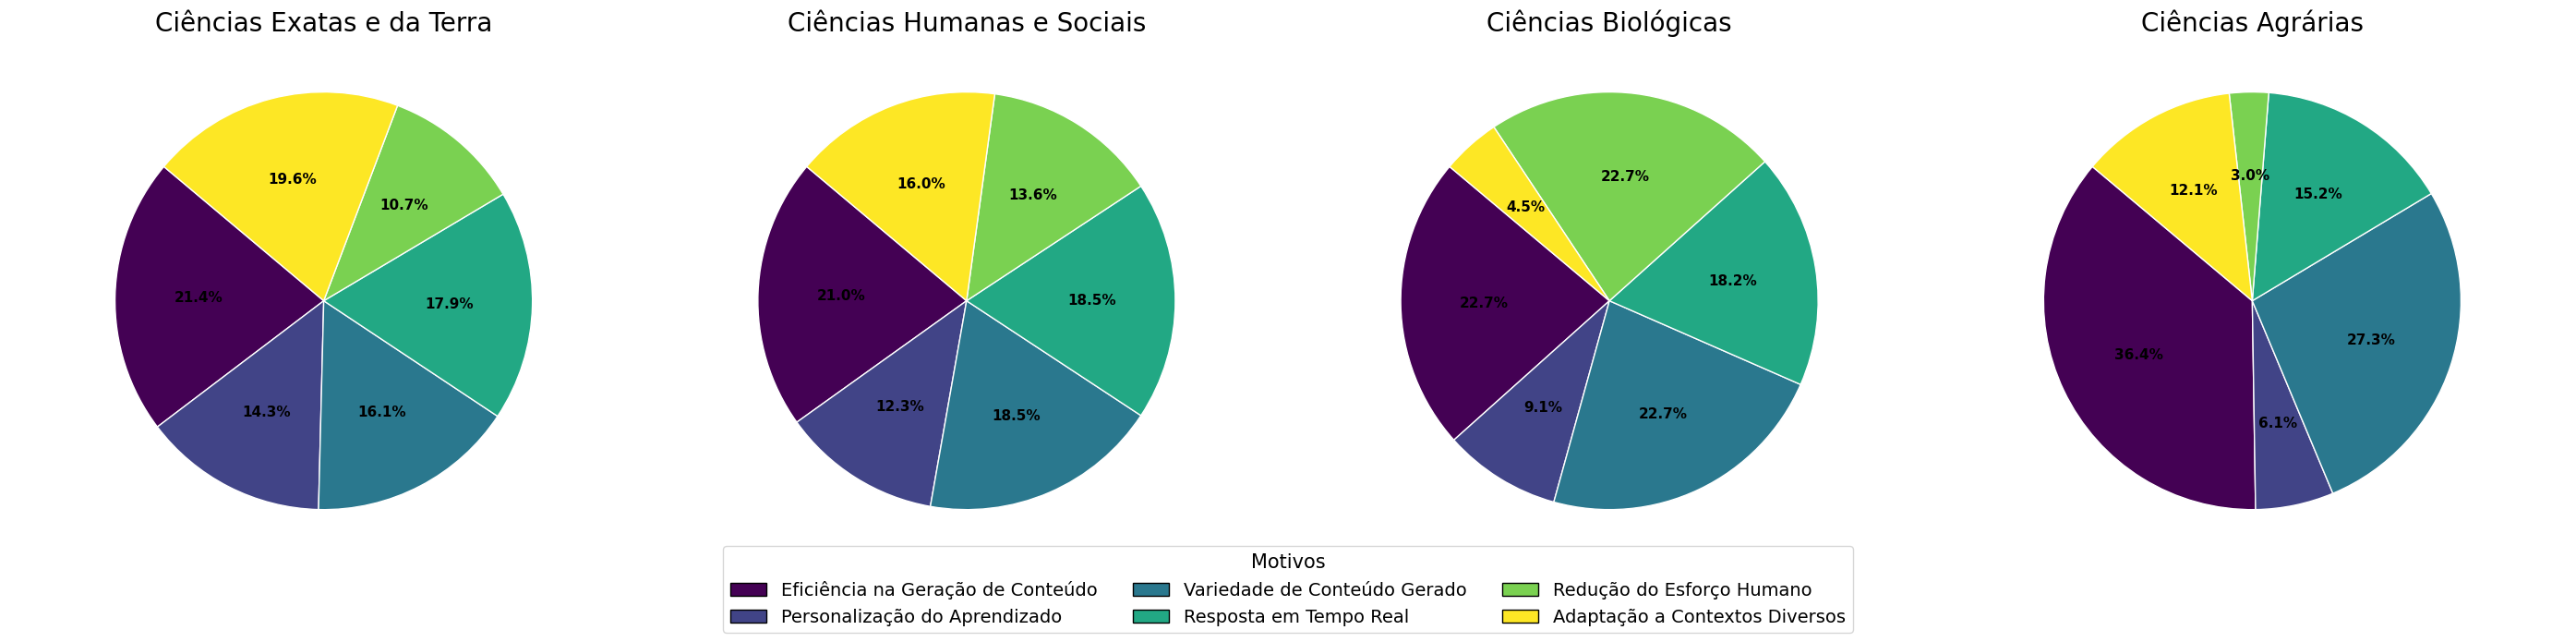


Dados do gráfico de motivos para considerar IA generativa melhor:

Área: Ciências Exatas e da Terra
Eficiência na Geração de Conteúdo: 12 (66.7%)
Personalização do Aprendizado: 8 (44.4%)
Variedade de Conteúdo Gerado: 9 (50.0%)
Resposta em Tempo Real: 10 (55.6%)
Redução do Esforço Humano: 6 (33.3%)
Adaptação a Contextos Diversos: 11 (61.1%)

Área: Ciências Humanas e Sociais
Eficiência na Geração de Conteúdo: 17 (54.8%)
Personalização do Aprendizado: 10 (32.3%)
Variedade de Conteúdo Gerado: 15 (48.4%)
Resposta em Tempo Real: 15 (48.4%)
Redução do Esforço Humano: 11 (35.5%)
Adaptação a Contextos Diversos: 13 (41.9%)

Área: Ciências Biológicas
Eficiência na Geração de Conteúdo: 5 (38.5%)
Personalização do Aprendizado: 2 (15.4%)
Variedade de Conteúdo Gerado: 5 (38.5%)
Resposta em Tempo Real: 4 (30.8%)
Redução do Esforço Humano: 5 (38.5%)
Adaptação a Contextos Diversos: 1 (7.7%)

Área: Ciências Agrárias
Eficiência na Geração de Conteúdo: 12 (54.5%)
Personalização do Aprendizado: 2 (9.1%)
Va

In [240]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Nome da coluna com a área agrupada (ajuste se necessário)
coluna_area = 'Área de Estudo Agrupada'

# Motivos que estamos procurando nas respostas
motivos = [
    'Eficiência na Geração de Conteúdo',
    'Personalização do Aprendizado',
    'Variedade de Conteúdo Gerado',
    'Resposta em Tempo Real',
    'Redução do Esforço Humano',
    'Adaptação a Contextos Diversos'
]

# Obter áreas únicas
areas = df[coluna_area].dropna().unique()
n_areas = len(areas)

# Configurar o grid para subplots lado a lado
fig, axs = plt.subplots(1, n_areas, figsize=(7 * n_areas, 7))

# Paleta de cores base
cmap = plt.get_cmap('viridis')
cores_base = cmap(np.linspace(0, 1, len(motivos)))

# Garantir que axs seja sempre uma lista (mesmo que só tenha uma área)
if n_areas == 1:
    axs = [axs]

for idx, area in enumerate(areas):
    ax = axs[idx]

    # Filtra as respostas daquela área
    respostas_area = df[df[coluna_area] == area]['Se sim, selecione os motivos que justificam por que a IA Generativa é considerada melhor que os métodos tradicionais'].dropna()

    # Contar os motivos nas respostas
    contagem_motivos_area = {motivo: respostas_area.str.contains(motivo, case=True).sum() for motivo in motivos}

    # Criar DataFrame
    df_motivos_area = pd.DataFrame({
        'Motivo': list(contagem_motivos_area.keys()),
        'Contagem': list(contagem_motivos_area.values())
    })

    df_motivos_area = df_motivos_area[df_motivos_area['Contagem'] > 0]  # Remove contagens zeradas

    if df_motivos_area.empty:
        ax.axis('off')
        ax.set_title(f'{area}\n(Sem respostas)')
        continue

    # Cores compatíveis com a ordem original
    cores_ativas = [cores_base[motivos.index(m)] for m in df_motivos_area['Motivo']]

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(
        df_motivos_area['Contagem'],
        labels=None,
        colors=cores_ativas,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops=dict(edgecolor='white')
    )

    # Ajustes de texto
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')

    ax.set_title(f'{area}', fontsize=20)
    ax.axis('equal')

# Legenda única abaixo de todos os gráficos
handles_legenda = [
    mpatches.Patch(facecolor=cores_base[i], edgecolor='black', label=motivos[i])
    for i in range(len(motivos))
]

fig.legend(handles=handles_legenda, title='Motivos', loc='lower center', ncol=3, fontsize=14, title_fontsize=15)

# Ajustes finais
plt.tight_layout(rect=[0, 0.1, 1, 1])  # Deixa espaço abaixo para a legenda
plt.show()

# imprimir os dados do gráfico
print("\nDados do gráfico de motivos para considerar IA generativa melhor:")
for area in areas:
    respostas_area = df[df[coluna_area] == area]['Se sim, selecione os motivos que justificam por que a IA Generativa é considerada melhor que os métodos tradicionais'].dropna()
    contagem_motivos_area = {motivo: respostas_area.str.contains(motivo, case=True).sum() for motivo in motivos}
    print(f"\nÁrea: {area}")
    for motivo, contagem in contagem_motivos_area.items():
        print(f"{motivo}: {contagem} ({(contagem / len(respostas_area)) * 100:.1f}%)")

### Satisfação com a Utilização de IA Generativa

C:\Users\Luise\AppData\Local\Temp\ipykernel_23136\126413285.py:81: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=cores_base[i], label=categorias[i], edgecolor='black')


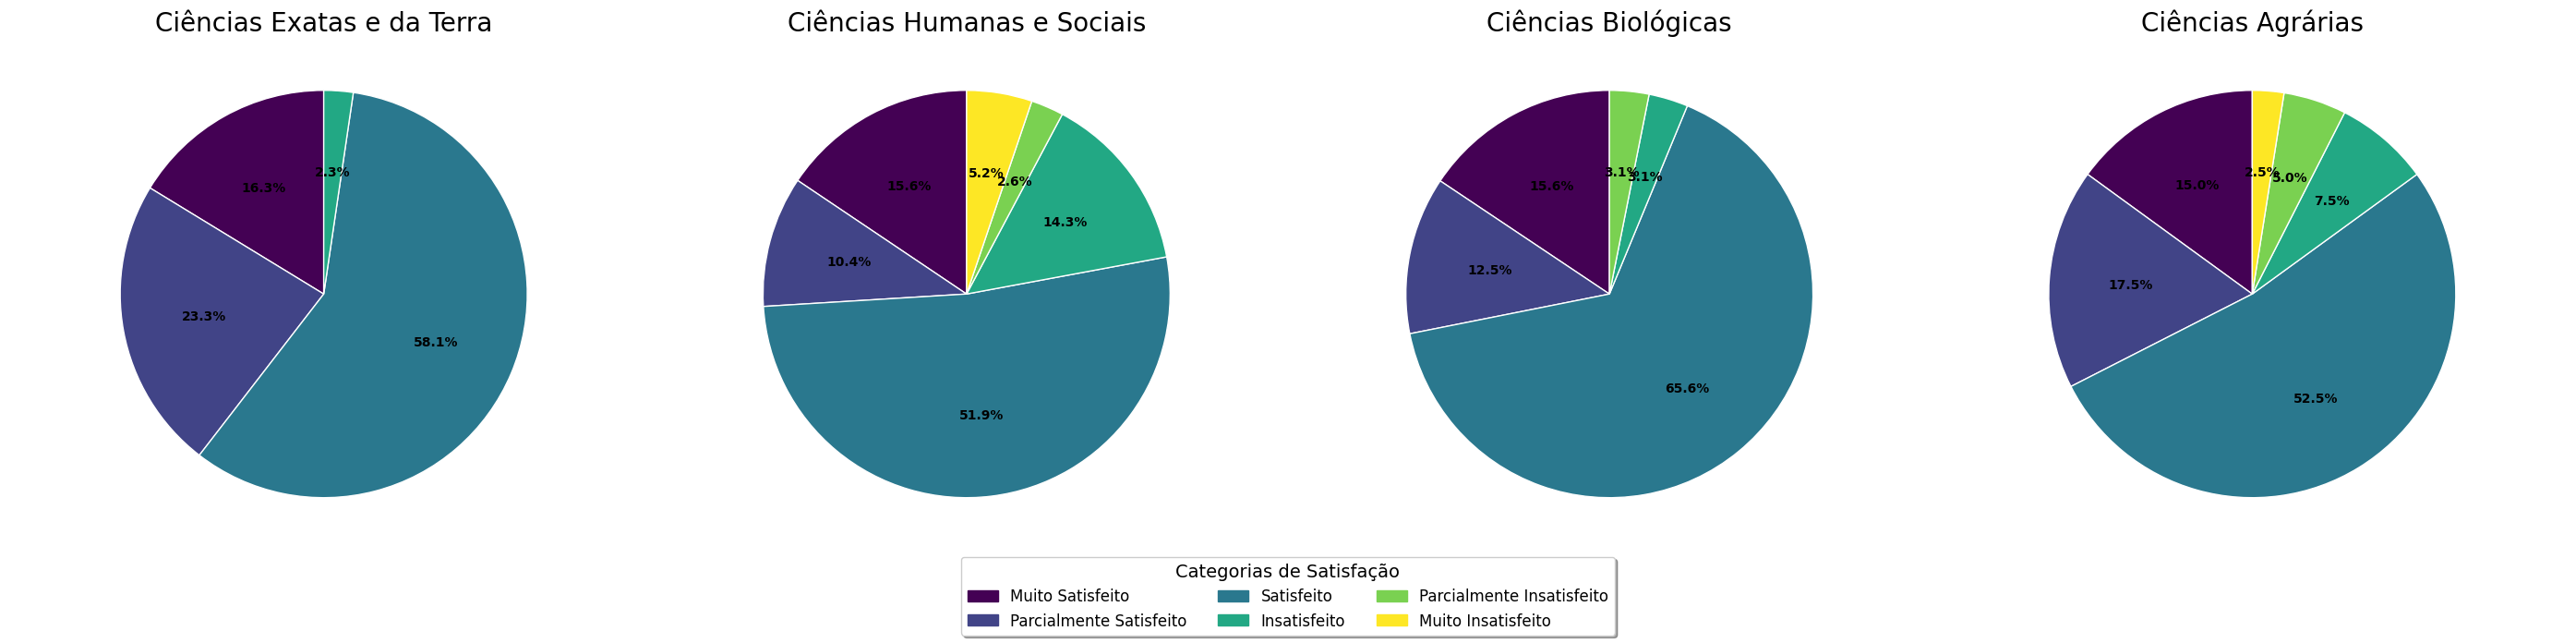


Dados do gráfico de satisfação com ferramentas de IA generativa:

Área: Ciências Exatas e da Terra
Muito Satisfeito: 7 (26.9%)
Parcialmente Satisfeito: 10 (38.5%)
Satisfeito: 25 (96.2%)
Insatisfeito: 1 (3.8%)
Parcialmente Insatisfeito: 0 (0.0%)
Muito Insatisfeito: 0 (0.0%)

Área: Ciências Humanas e Sociais
Muito Satisfeito: 12 (23.5%)
Parcialmente Satisfeito: 8 (15.7%)
Satisfeito: 40 (78.4%)
Insatisfeito: 11 (21.6%)
Parcialmente Insatisfeito: 2 (3.9%)
Muito Insatisfeito: 4 (7.8%)

Área: Ciências Biológicas
Muito Satisfeito: 5 (22.7%)
Parcialmente Satisfeito: 4 (18.2%)
Satisfeito: 21 (95.5%)
Insatisfeito: 1 (4.5%)
Parcialmente Insatisfeito: 1 (4.5%)
Muito Insatisfeito: 0 (0.0%)

Área: Ciências Agrárias
Muito Satisfeito: 6 (25.0%)
Parcialmente Satisfeito: 7 (29.2%)
Satisfeito: 21 (87.5%)
Insatisfeito: 3 (12.5%)
Parcialmente Insatisfeito: 2 (8.3%)
Muito Insatisfeito: 1 (4.2%)


In [241]:
# Coluna da área agrupada (ajuste se necessário)
coluna_area = 'Área de Estudo Agrupada'

# Categorias de satisfação
categorias = [
    'Muito Satisfeito',
    'Parcialmente Satisfeito',
    'Satisfeito',
    'Insatisfeito',
    'Parcialmente Insatisfeito',
    'Muito Insatisfeito'
]

# Paleta de cores fixa e ordenada
cmap = plt.get_cmap('viridis')
cores_base = cmap(np.linspace(0, 1, len(categorias)))

# Função para gerar rótulos de porcentagem
def func_autopct(pct):
    return f'{pct:.1f}%'

# Obter áreas únicas
areas = df[coluna_area].dropna().unique()
n_areas = len(areas)

# Configurar a figura e os subplots
fig, axs = plt.subplots(1, n_areas, figsize=(7 * n_areas, 7))

# Garante que axs seja uma lista mesmo com 1 subplot
if n_areas == 1:
    axs = [axs]

for idx, area in enumerate(areas):
    ax = axs[idx]

    # Filtra respostas da área
    respostas_area = df[df[coluna_area] == area]['No geral, como você avalia sua experiência ao utilizar ferramentas de IA generativa no ensino superior?'].dropna()

    # Contar categorias
    contagem = {
        cat: respostas_area.str.contains(r'\b' + cat + r'\b', case=True).sum()
        for cat in categorias
    }

    df_area = pd.DataFrame({
        'Categoria': list(contagem.keys()),
        'Contagem': list(contagem.values())
    })
    df_area['Porcentagem'] = (df_area['Contagem'] / df_area['Contagem'].sum()) * 100
    df_area = df_area[df_area['Contagem'] > 0]

    if df_area.empty:
        ax.axis('off')
        ax.set_title(f'{area}\n(Sem respostas)')
        continue

    # Cores para categorias presentes
    cores_ativas = [cores_base[categorias.index(cat)] for cat in df_area['Categoria']]

    # Gráfico de pizza
    wedges, texts, autotexts = ax.pie(
        df_area['Contagem'],
        labels=None,
        autopct=func_autopct,
        startangle=90,
        colors=cores_ativas,
        textprops={'weight': 'bold', 'color': 'black'},
        wedgeprops=dict(edgecolor='white')
    )

    # Ajustar manualmente rótulos de porcentagem pequenos (<1%)
    for i, text in enumerate(autotexts):
        if df_area['Porcentagem'].iloc[i] < 1:
            text.set_position((text.get_position()[0] * 1.4, text.get_position()[1] * 1.4))

    ax.set_title(f'{area}', fontsize=20)
    ax.axis('equal')

# Criar legenda única abaixo dos gráficos
patches_list = [
    mpatches.Patch(color=cores_base[i], label=categorias[i], edgecolor='black')
    for i in range(len(categorias))
]
fig.legend(
    handles=patches_list, 
    title="Categorias de Satisfação", 
    loc='lower center', 
    ncol=3, 
    fontsize=12, 
    title_fontsize=14,
    fancybox=True,
    shadow=True
    )

# Ajuste de layout
plt.tight_layout(rect=[0, 0.12, 1, 1])  # deixa espaço inferior para legenda
plt.show()

# imprimir os dados do gráfico
print("\nDados do gráfico de satisfação com ferramentas de IA generativa:")
for area in areas:
    respostas_area = df[df[coluna_area] == area]['No geral, como você avalia sua experiência ao utilizar ferramentas de IA generativa no ensino superior?'].dropna()
    contagem = {
        cat: respostas_area.str.contains(r'\b' + cat + r'\b', case=True).sum()
        for cat in categorias
    }
    print(f"\nÁrea: {area}")
    for categoria, contagem in contagem.items():
        print(f"{categoria}: {contagem} ({(contagem / len(respostas_area)) * 100:.1f}%)")

### Resposta aberta com opniões sobre IAG

c:\Users\Luise\OneDrive\Documentos\GitHub\Analise-TCC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


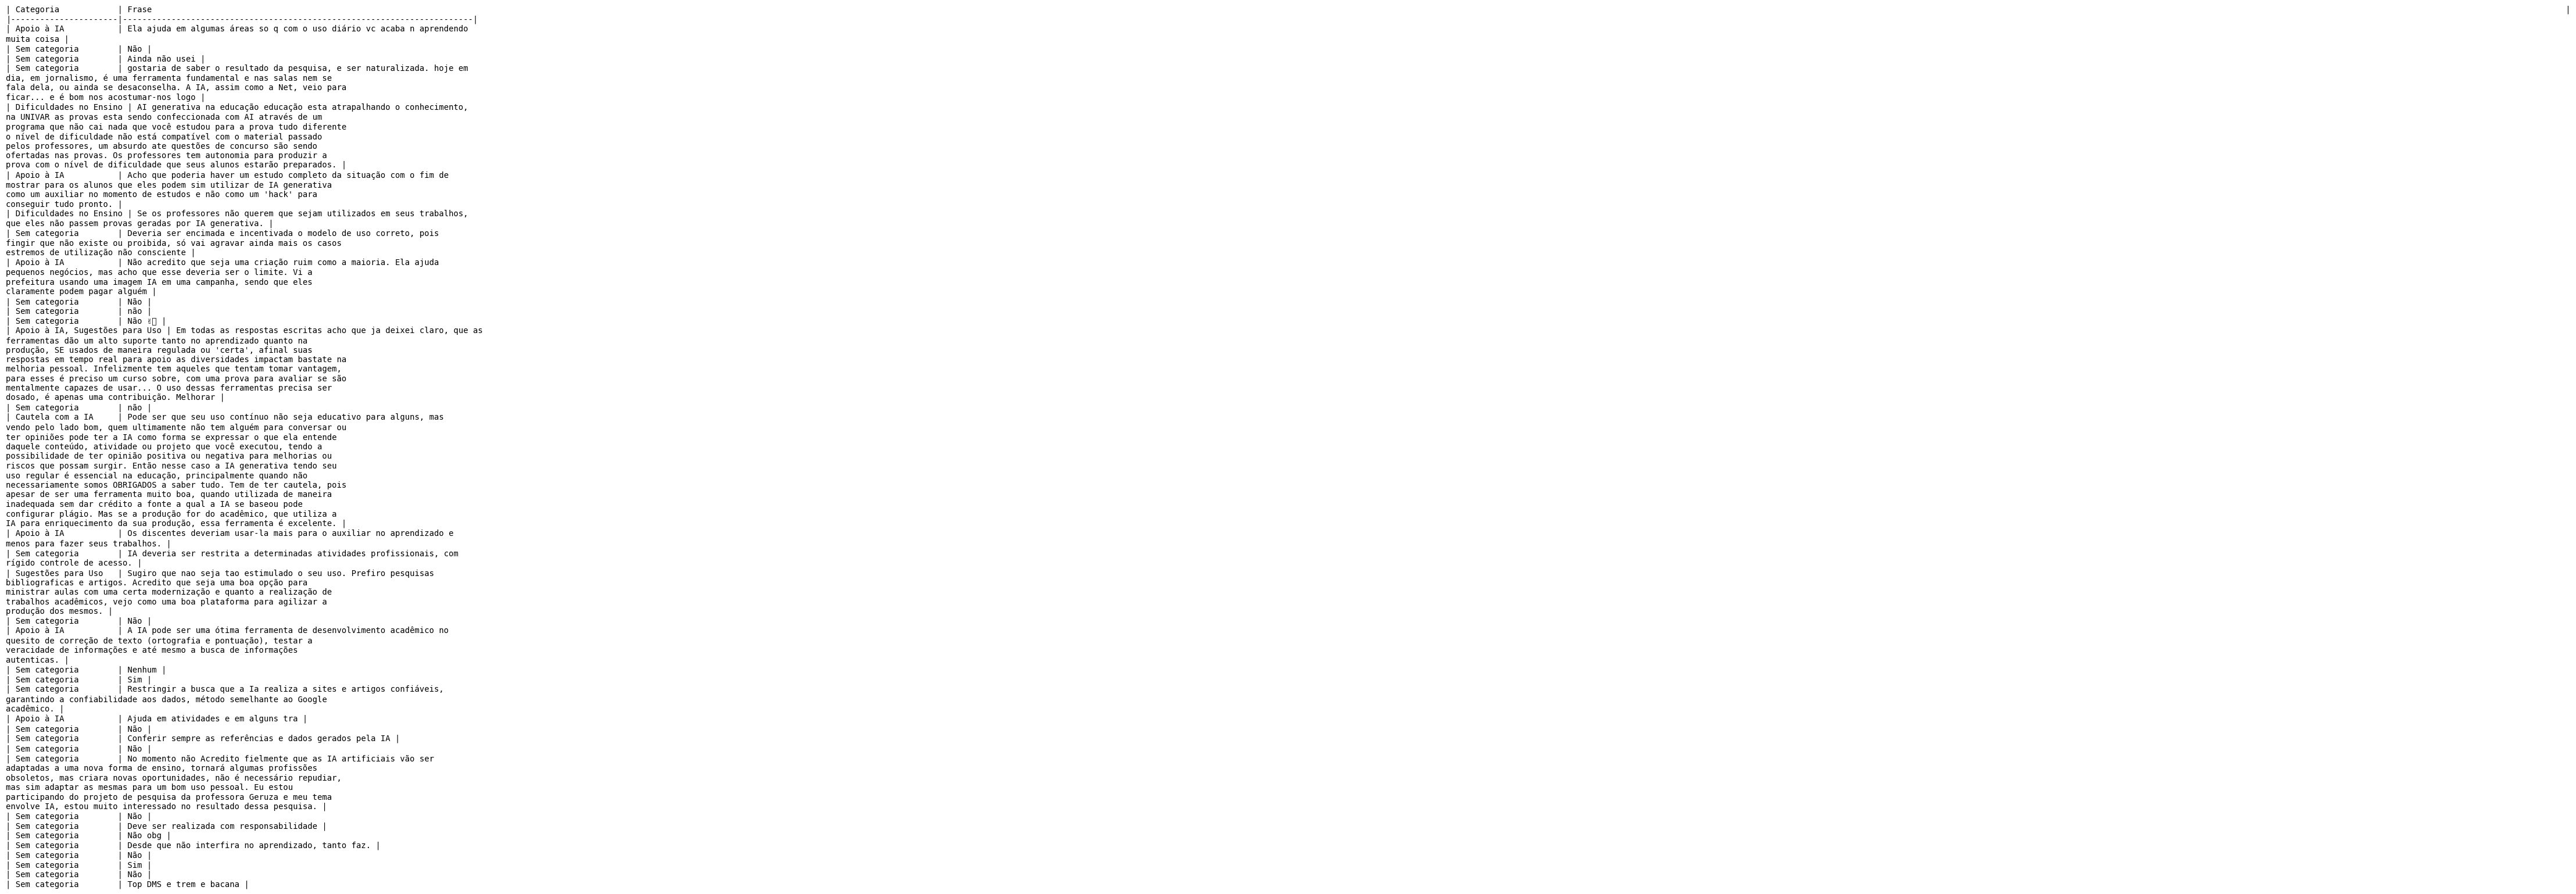

In [181]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import textwrap

# Lista com as frases (cada elemento representa uma resposta)
frases = [
    "Ela ajuda em algumas áreas so q com o uso diário vc acaba n aprendendo muita coisa",
    "Não",
    "Ainda não usei",
    "gostaria de saber o resultado da pesquisa, e ser naturalizada. hoje em dia, em jornalismo, é uma ferramenta fundamental e nas salas nem se fala dela, ou ainda se desaconselha. A IA, assim como a Net, veio para ficar... e é bom nos acostumar-nos logo",
    "AI generativa na educação educação esta atrapalhando o conhecimento, na UNIVAR as provas esta sendo confeccionada com AI através de um programa que não cai nada que você estudou para a prova tudo diferente o nível de dificuldade não está compatível com o material passado pelos professores, um absurdo ate questões de concurso são sendo ofertadas nas provas. Os professores tem autonomia para produzir a prova com o nível de dificuldade que seus alunos estarão preparados.",
    "Acho que poderia haver um estudo completo da situação com o fim de mostrar para os alunos que eles podem sim utilizar de IA generativa como um auxiliar no momento de estudos e não como um 'hack' para conseguir tudo pronto.",
    "Se os professores não querem que sejam utilizados em seus trabalhos, que eles não passem provas geradas por IA generativa.",
    "Deveria ser encimada e incentivada o modelo de uso correto, pois fingir que não existe ou proibida, só vai agravar ainda mais os casos estremos de utilização não consciente",
    "Não acredito que seja uma criação ruim como a maioria. Ela ajuda pequenos negócios, mas acho que esse deveria ser o limite. Vi a prefeitura usando uma imagem IA em uma campanha, sendo que eles claramente podem pagar alguém",
    "Não",
    "não",
    "Não ✌️",
    "Em todas as respostas escritas acho que ja deixei claro, que as ferramentas dão um alto suporte tanto no aprendizado quanto na produção, SE usados de maneira regulada ou 'certa', afinal suas respostas em tempo real para apoio as diversidades impactam bastate na melhoria pessoal. Infelizmente tem aqueles que tentam tomar vantagem, para esses é preciso um curso sobre, com uma prova para avaliar se são mentalmente capazes de usar... O uso dessas ferramentas precisa ser dosado, é apenas uma contribuição. Melhorar",
    "não",
    "Pode ser que seu uso contínuo não seja educativo para alguns, mas vendo pelo lado bom, quem ultimamente não tem alguém para conversar ou ter opiniões pode ter a IA como forma se expressar o que ela entende daquele conteúdo, atividade ou projeto que você executou, tendo a possibilidade de ter opinião positiva ou negativa para melhorias ou riscos que possam surgir. Então nesse caso a IA generativa tendo seu uso regular é essencial na educação, principalmente quando não necessariamente somos OBRIGADOS a saber tudo. Tem de ter cautela, pois apesar de ser uma ferramenta muito boa, quando utilizada de maneira inadequada sem dar crédito a fonte a qual a IA se baseou pode configurar plágio. Mas se a produção for do acadêmico, que utiliza a IA para enriquecimento da sua produção, essa ferramenta é excelente.",
    "Os discentes deveriam usar-la mais para o auxiliar no aprendizado e menos para fazer seus trabalhos.",
    "IA deveria ser restrita a determinadas atividades profissionais, com rígido controle de acesso.",
    "Sugiro que nao seja tao estimulado o seu uso. Prefiro pesquisas bibliograficas e artigos. Acredito que seja uma boa opção para ministrar aulas com uma certa modernização e quanto a realização de trabalhos acadêmicos, vejo como uma boa plataforma para agilizar a produção dos mesmos.",
    "Não",
    "A IA pode ser uma ótima ferramenta de desenvolvimento acadêmico no quesito de correção de texto (ortografia e pontuação), testar a veracidade de informações e até mesmo a busca de informações autenticas.",
    "Nenhum",
    "Sim",
    "Restringir a busca que a Ia realiza a sites e artigos confiáveis, garantindo a confiabilidade aos dados, método semelhante ao Google acadêmico.",
    "Ajuda em atividades e em alguns tra",  # frase incompleta conforme o original
    "Não",
    "Conferir sempre as referências e dados gerados pela IA",
    "Não",
    "No momento não Acredito fielmente que as IA artificiais vão ser adaptadas a uma nova forma de ensino, tornará algumas profissões obsoletos, mas criara novas oportunidades, não é necessário repudiar, mas sim adaptar as mesmas para um bom uso pessoal. Eu estou participando do projeto de pesquisa da professora Geruza e meu tema envolve IA, estou muito interessado no resultado dessa pesquisa.",
    "Não",
    "Deve ser realizada com responsabilidade",
    "Não obg",
    "Desde que não interfira no aprendizado, tanto faz.",
    "Não",
    "Sim",
    "Não",
    "Top DMS e trem e bacana"
]

# Cria o DataFrame com as frases
df = pd.DataFrame({'Frase': frases})

# Define as categorias exatamente como fornecidas
categorias = {
    'Apoio à IA': ['ajuda', 'ótima ferramenta', 'suporte', 'auxiliar', 'alto suporte'],
    'Cautela com a IA': ['plágio', 'inadequada', 'cuidado', 'risco'],
    'Dificuldades no Ensino': ['dificuldades', 'provas', 'nível de dificuldade'],
    'Sugestões para Uso': ['sugestão', 'recomenda', 'melhorar', 'modernização']
}

# Função para categorizar a frase com base nas palavras-chave
def categorizar(frase):
    resultados = []
    for categoria, palavras in categorias.items():
        for palavra in palavras:
            # Busca pela palavra isolada, ignorando diferenças de maiúsculas/minúsculas
            if re.search(r'\b' + re.escape(palavra) + r'\b', frase, re.IGNORECASE):
                resultados.append(categoria)
                break
    return ", ".join(resultados) if resultados else "Sem categoria"

# Aplica a categorização para cada frase
df['Categoria'] = df['Frase'].apply(categorizar)

# Monta a tabela formatada com header e cada linha no formato:
# | Categoria | Frase |
wrapper = textwrap.TextWrapper(width=70)
linhas_tabela = []

# Header da tabela
header = f"| {'Categoria':<20} | {'Frase':<500} |"
separator = f"|{'-'*22}|{'-'*72}|"
linhas_tabela.append(header)
linhas_tabela.append(separator)

# Para cada linha do DataFrame, formata a saída com wrap na frase
for idx, row in df.iterrows():
    categoria = row['Categoria']
    # Faz wrap no texto da frase para quebrar em múltiplas linhas, se necessário.
    frase_wrapped = wrapper.fill(row['Frase'])
    linha = f"| {categoria:<20} | {frase_wrapped:<2} |"
    linhas_tabela.append(linha)

# Junta todas as linhas em uma única string
tabela_str = "\n".join(linhas_tabela)

# Cria uma figura e exibe a string da tabela
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')  # Remove os eixos
ax.text(0, 1, tabela_str, fontsize=10, family='monospace', va='top')
plt.show()
